# FastPart — Part 2: Two-Layer Neural Networks on California Housing

**Paper:** *FastPart: Over-Parametrized Stochastic Gradient Descent for Sparse Optimization on Measures*  
De Castro, Gadat & Marteau, 2024

---

## Overview

This notebook is a **self-contained** reproduction of the neural-network regression experiment
from the FastPart paper.
We apply the **FastPart** algorithm — a Stochastic & Random-Feature variant of
**Conic Particle Gradient Descent (CPGD)** — to the *California Housing* benchmark,
comparing it to its full-batch counterpart.

### Beurling LASSO (BLASSO) objective

The algorithm minimises the following functional over the space of signed Radon measures:

$$
J(\nu) \;=\; \frac{1}{2}\,\|y - \Phi(\nu)\|_{\mathbb H}^2
\;+\; \lambda\,\|\nu\|_{\mathrm{TV}}
$$

where:

- $\Phi(\nu) = \int \varphi_\theta\,\mathrm d\nu(\theta)$ is the **kernel measure embedding**
  (a bounded linear map under a continuity assumption on the feature map),
- $\lambda > 0$ is the TV-norm regularisation weight (promoting sparsity,
  analogous to $\ell^1$-regularisation in high-dimensional statistics).

The existence of a minimiser $\mu^\star$ is guaranteed under mild assumptions,
extending classical results (Bredies–Pikkarainen 2013, Hofmann et al. 2007)
under the continuity of the feature map.

### Neural-network interpretation

In this experiment the feature map is an **affine ReLU neuron**:

$$
\varphi_\theta(x) \;=\; \mathrm{ReLU}(\langle w, x\rangle + b),
\qquad \theta = (w, b) \in \mathcal{X} = \bar{B}(0,1) \subset \mathbb{R}^{d+1}
$$

so the predicted function is a **two-layer ReLU network**:

$$
f_\nu(x) \;=\; \sum_{i=1}^p \varepsilon_i\,\omega_i\,\mathrm{ReLU}(\langle w_i,\, x\rangle + b_i)
$$

where $\varepsilon_i \in \{-1, +1\}$ are **fixed** signs
(symmetrisation argument, Chizat 2022),
$\omega_i > 0$ are the particle amplitudes,
and $\theta_i = (w_i, b_i) \in \mathbb{R}^{d+1}$ are the affine neuron parameters (positions on the unit ball).

### Notebook structure

| Section | Content |
|---------|-------------------------------------------------------------|
| 1 | Imports & base CPGD infrastructure |
| 2 | California Housing dataset loading & preprocessing |
| 3 | `NNBlasso` problem class (kernel, $J'$, gradients) |
| 4 | Problem & particle initialisation |
| 5 | Full-Batch CPGD for comparison |
| 6 | Stochastic CPGD optimizer (`StochasticNNOptimizer`) |
| 7 | Training with Stochastic CPGD |
| 8 | Convergence plots |
| 9 | Weight distribution & sparsity analysis |
| 10 | Experiment summary |
| 11 | Birth–Death process |
| 12 | Four-way comparison (standard vs Birth–Death) |
| 13 | Dual certificate |

## 1. Imports & Base Infrastructure

We load PyTorch, NumPy, and Matplotlib, and define the **general CPGD infrastructure**
shared across all experiments in the paper:

- **`Particles`** — a `torch.nn.Module` encoding the discrete measure
  $\mu_p = \sum_i \varepsilon_i\, h(r_i)\,\delta_{\theta_i}$.  
  Positions $\theta_i$ and raw weights $r_i$ are `nn.Parameter`s;
  the *amplitude* $\omega_i = h(r_i)$ is the effective weight entering $J$.
- **`MirrorRetraction`** — implements the multiplicative weight update
  $\omega_i \leftarrow \omega_i\,e^{\Delta r_i}$,
  guaranteeing positivity of weights throughout the descent.
- **`L2Blasso`** — abstract base class for any BLASSO problem with squared
  $\ell^2$ data fidelity; subclasses only need to implement `kernel` and `scalar_products`.
- **`ModelEvaluation`** — lazy-evaluated (via `@cached_property`) computation of
  $J'_\nu$, $\nabla_\theta J'_\nu$, and squared gradient accumulators (for potential use with Adagrad-type step sizes).


In [ ]:
# Install required dependencies (if needed)
import sys
!{sys.executable} -m pip install --upgrade pip --quiet
!{sys.executable} -m pip install torch torchvision jaxtyping --quiet
!{sys.executable} -m pip install numpy matplotlib scikit-learn --quiet

: 

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Any, Callable, TypeVar, Generic, ClassVar
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
from functools import cached_property
from collections.abc import Callable as CallableABC
from torch.nn import Module, Parameter
from torch import Tensor
from jaxtyping import Float, Int
import time

# Configuration
torch.manual_seed(314)
np.random.seed(314)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================================
# RETRACTION CLASSES
# ============================================================================

class Retraction:
    """Define a retraction on weights x position as in Chizat 2020."""

    def __call__(
        self, positions: Tensor, weights: Tensor, dpositions: Tensor, dweights: Tensor
    ) -> None:
        # Modification in-place
        positions += dpositions
        weights += dweights


class MirrorRetraction(Retraction):
    def __call__(
        self, positions: Tensor, weights: Tensor, dpositions: Tensor, dweights: Tensor
    ) -> None:
        positions += dpositions
        weights *= torch.exp(dweights)


# ============================================================================
# PARTICLES CLASS
# ============================================================================

class Particles(Module):
    r"""
    A class for encoding discrete measure
    $$
        \mu_p = \sum_i \epsilon_i h(r_i) \delta_{\theta_i}
    $$
    where $\epsilon_i$ is a sign, $r_i$ is a weight and $\theta_i$ a position.
    """

    def __init__(
        self,
        h: Callable[[Float[Tensor, " n_particles"]], Float[Tensor, " n_particles"]],
        positions: Float[Tensor, "n_particles dim"],
        weights: Float[Tensor, " n_particles"],
        signs: Int[Tensor, " n_particles"],
    ):
        n_particles, _ = positions.shape
        assert weights.shape == (n_particles,)
        assert signs.shape == (n_particles,)

        super().__init__()
        self.h = h
        self.positions = Parameter(positions)
        self.weights = Parameter(weights)
        self.signs = signs
        self.gradient_evaluation = None

    @staticmethod
    def from_randn(
        h: Callable,
        dimension: int,
        n_particles: int,
        position_sigma: float = 1.0,
        weight_sigma: float = 1.0,
        **kwargs: Any,
    ) -> "Particles":
        positions = Parameter(
            position_sigma * torch.randn((n_particles, dimension), **kwargs)
        )
        weights = Parameter(weight_sigma * torch.randn(n_particles, **kwargs).abs())
        signs = 2.0 * torch.randint(2, size=(n_particles,)) - 1
        return Particles(h, positions, weights, signs)

    @property
    def amplitudes(self) -> Float[Tensor, " n_particles"]:
        """This is the true weights $a_i=h(r_i)$ in front of each Diracs."""
        return self.h(self.weights)

    @property
    def amplitudes_deriv(self) -> Float[Tensor, " n_particles"]:
        """The derivative of the particle's h function"""
        with torch.enable_grad():
            amplitudes = self.amplitudes
            return torch.autograd.grad(
                amplitudes,
                self.weights,
                grad_outputs=torch.ones_like(amplitudes),
            )[0]

    def __len__(self) -> int:
        return self.positions.size(0)

    def __getitem__(self, idx: Any) -> "Particles":
        if isinstance(idx, int):
            idx = [idx]

        return Particles(
            self.h,
            self.positions[idx, ...],
            self.weights[idx, ...],
            self.signs[idx, ...],
        )

    def tv_norm(self) -> Float[Tensor, "1"]:
        r"""Returns the TV-norm of the discrete particle measure."""
        return self.amplitudes.abs().sum()

    def __repr__(self) -> str:
        return f"{type(self).__name__}(positions={self.positions.data}, weights={self.weights.data}, signs={self.signs.data})"

    def clone(self, *, detach: bool = True) -> "Particles":
        """Return a copy of Particles"""
        if detach:
            positions = self.positions.detach().clone()
            weights = self.weights.detach().clone()
        else:
            positions = self.positions.clone()
            weights = self.weights.clone()

        signs = self.signs.clone()

        return Particles(
            h=self.h,
            positions=positions,
            weights=weights,
            signs=signs,
        )


# ============================================================================
# BASE PROBLEM CLASSES
# ============================================================================

TProblem = TypeVar("TProblem", bound="BlassoProblem", covariant=True)


@dataclass
class ModelEvaluation(Generic[TProblem]):
    """Define an evaluation context when computing the loss."""

    problem: TProblem
    particles: Particles

    def set_particles_gradient(
        self,
        dweights: Float[Tensor, " n_particles"],
        dpositions: Float[Tensor, "n_particles dim"],
    ) -> None:
        """Defines the gradient of the particles properties"""
        self.particles.weights.grad = dweights
        self.particles.positions.grad = dpositions
        self.particles.gradient_evaluation = self

    @cached_property
    def proximity(self) -> Float[Tensor, "1"]:
        raise NotImplementedError

    @cached_property
    def lasso(self) -> Float[Tensor, "1"]:
        return self.problem.kappa * self.particles.tv_norm()

    @cached_property
    def loss(self) -> Float[Tensor, "1"]:
        return self.proximity + self.lasso

    @cached_property
    def Fm_backward(self) -> None:
        # By default using PyTorch auto-diff
        dweights, dpositions = torch.autograd.grad(
            self.loss,
            [self.particles.weights, self.particles.positions],
        )
        self.set_particles_gradient(dweights, dpositions)

    @cached_property
    def amplitudes(self) -> Float[Tensor, " n_particles"]:
        """The particle's h function"""
        return self.particles.amplitudes

    @cached_property
    def amplitudes_deriv(self) -> Float[Tensor, " n_particles"]:
        """The derivative of the particle's h function"""
        return self.particles.amplitudes_deriv

    @cached_property
    def Jp(self) -> Float[Tensor, " n_particles"]:
        """The J' function applied to the particle positions"""
        raise NotImplementedError

    @cached_property
    def Jp_grad(self) -> Float[Tensor, "n_particles dim"]:
        """The gradient of J' applied the particle positions"""
        from torch import autograd

        jac = autograd.grad(
            self.Jp,
            self.particles.positions,
            grad_outputs=torch.eye(len(self.Jp)),
            is_grads_batched=True,
            retain_graph=True,
        )[0]

        extract = torch.arange(len(self.particles))
        grad_jp_autodiff = jac[extract, extract, :]

        return grad_jp_autodiff

    @cached_property
    def Jp_backward(self) -> None:
        """Fill parameter .grad with gradient computed from J'"""
        self.set_particles_gradient(
            dweights=self.amplitudes_deriv * self.Jp,
            dpositions=self.amplitudes.unsqueeze(-1) * self.Jp_grad,
        )

    @cached_property
    def loss_backward(self) -> None:
        """Computation of the gradient of the loss"""
        try:
            self.Jp_backward
        except NotImplementedError:
            self.Fm_backward

    @cached_property
    def loss_gradient(self) -> list[Tensor]:
        """Gradient of the loss as the list of gradient's part for each parameter"""
        self.loss_backward
        return [p.grad for p in self.particles.parameters()]

    def backward(self) -> None:
        """For compatibility reason with vanilla PyTorch code"""
        self.loss_backward

    def item(self) -> float:
        """For compatibility reason with vanilla PyTorch code"""
        return self.loss.item()


@dataclass
class BlassoProblem(ABC):
    """Base class for a blasso problem with associated loss"""

    Evaluation: ClassVar[type[ModelEvaluation]] = ModelEvaluation

    kappa: float  # lasso weight

    def __call__(self, particles: Particles) -> ModelEvaluation:
        """Evaluation of the problem for the given particles"""
        return self.Evaluation(self, particles)


# ============================================================================
# L2 BLASSO
# ============================================================================

Observation = TypeVar("Observation")


@dataclass
class L2Blasso(BlassoProblem, Generic[Observation]):
    y: Observation
    loss_offset: float = field(init=False, default=0)

    @dataclass
    class Evaluation(ModelEvaluation["L2Blasso"]):
        @cached_property
        @abstractmethod
        def kernel(self) -> Float[Tensor, "n_particles n_particles"]:
            """User specify how to compute the kernel"""
            ...

        @cached_property
        def _kernel(self) -> Float[Tensor, "n_particles n_particles"]:
            """Internal wrapper on self.kernel()"""
            return self.kernel

        @cached_property
        @abstractmethod
        def scalar_products(self) -> Float[Tensor, " n_particles"]:
            r"""Return scalar products $(<y, \phi_{position_i}>)_{i=1}^{n_particles}$"""
            ...

        @cached_property
        def l2_cost(self) -> Float[Tensor, "1"]:
            amplitudes = self.particles.amplitudes
            kernel_matrix = self._kernel
            k_target = self.scalar_products
            quadratic_term = 0.5 * amplitudes.matmul(kernel_matrix.matmul(amplitudes))
            linear_term = amplitudes @ k_target
            return quadratic_term - linear_term + self.problem.loss_offset

        @cached_property
        def proximity(self) -> Float[Tensor, "1"]:
            return self.l2_cost


# ============================================================================
# OPTIMIZERS
# ============================================================================

@dataclass
class Optimizer(ABC):
    particles: Particles

    def zero_grad(self) -> None:
        self.particles.zero_grad()

    @abstractmethod
    def step(self) -> None: ...


@dataclass
class ConicOptimizer(Optimizer):
    alpha: float
    beta: float
    retraction: Retraction = field(default_factory=Retraction)

    def step(self) -> None:
        positions, weights = self.particles.positions, self.particles.weights
        amplitudes = self.particles.amplitudes
        amplitudes_deriv = self.particles.amplitudes_deriv

        assert positions.grad is not None
        assert weights.grad is not None
        assert self.particles.gradient_evaluation is not None

        with torch.no_grad():
            try:
                grad_weights = self.alpha * self.particles.gradient_evaluation.Jp
            except NotImplementedError:
                grad_weights = self.alpha * weights.grad / amplitudes_deriv
                grad_weights[amplitudes_deriv == 0] = 0

            try:
                grad_positions = self.beta * self.particles.gradient_evaluation.Jp_grad
            except NotImplementedError:
                grad_positions = self.beta / amplitudes.unsqueeze(-1) * positions.grad
                grad_positions[amplitudes == 0] = 0

            self.retraction(positions, weights, -grad_positions, -grad_weights)


@dataclass
class AdagradConicOptimizer(Optimizer):
    """Adagrad variant of conic optimizer with adaptive learning rates."""
    problem: Any  # DiagonalGMMRiemannianBlasso
    eta: float
    eps: float = 1e-8

    def __post_init__(self):
        # Initialize accumulators with same shape as parameters
        self.v_positions = torch.zeros_like(self.particles.weights)
        self.v_weights = torch.zeros_like(self.particles.weights)
        self.retraction = MirrorRetraction()

    def step(self) -> None:
        positions = self.particles.positions
        n_particles, total_dim = positions.shape
        d = total_dim // 2
        weights = self.particles.weights

        eta = self.eta

        with torch.no_grad():
            eval = self.particles.gradient_evaluation
            
            # Accumulate squared gradients
            self.v_positions.add_(torch.mean(eval.Jp_grad2, dim=-1))
            self.v_weights.add_(eval.Jp2)

            # Scaled steps with adaptive learning rates
            dpositions = (
                -eta
                * eval.Jp_grad
                / (self.v_positions.sqrt().unsqueeze(-1) + self.eps)
            )
            dweights = -eta * eval.Jp / (self.v_weights.sqrt() + self.eps)

            # Retract
            self.retraction(positions, weights, dpositions, dweights)
            # Take absolute values for sigmas
            positions[:, d:] = self.problem.tau * torch.ones_like(positions[:, d:])


print("✓ All classes and functions loaded successfully!")


Using device: cpu
✓ All classes and functions loaded successfully!


## 2. California Housing Dataset

The **California Housing** dataset (Pace & Barry, 1997) contains $N = 20{,}640$
census-block observations from the 1990 California census.
Each sample has $d = 8$ features:

| Feature | Description |
|---------|-------------|
| `MedInc` | Median income in block (tens of thousands of dollars) |
| `HouseAge` | Median house age in block |
| `AveRooms` | Average rooms per household |
| `AveBedrms` | Average bedrooms per household |
| `Population` | Block population |
| `AveOccup` | Average household occupancy |
| `Latitude` | Block latitude |
| `Longitude` | Block longitude |

**Target:** median house value (hundreds of thousands of dollars).

We use a $90/10$ train/test split ($18{,}576$ / $2{,}064$ samples)
and **standardise** each feature to zero mean and unit variance.

> **Connection to the paper.** The paper considers regression with
> $\mathbb{H} = \mathbb{R}^N$ and normalised inner product
> $\langle u, v\rangle_{\mathbb H} = \frac{1}{N}\sum_{k=1}^N u_k v_k$,
> so that the BLASSO objective reduces to regularised mean squared error.


In [3]:
# Load California Housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
housing = fetch_california_housing()
X, y = housing.data, housing.target

print(f"Dataset shape: {X.shape}")
print(f"Features: {housing.feature_names}")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")

# Split into train and test sets (as in the paper: 18,576 train + 2,064 test = 20,640 total)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=314
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(f"\nTarget statistics:")
print(f"  Train mean: {y_train_tensor.mean():.4f}, std: {y_train_tensor.std():.4f}")
print(f"  Test mean: {y_test_tensor.mean():.4f}, std: {y_test_tensor.std():.4f}")

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Number of samples: 20640
Number of features: 8

Train set: (18576, 8)
Test set: (2064, 8)

Target statistics:
  Train mean: 2.0676, std: 1.1536
  Test mean: 2.0773, std: 1.1571


## 3. Neural-Network BLASSO Problem Definition

### Empirical kernel and scalar products

For the affine ReLU feature map $\varphi_\theta(x) = \mathrm{ReLU}(\langle w, x\rangle + b)$
with $\theta = (w, b) \in \mathbb{R}^{d+1}$,
the kernel and scalar products become:

$$
\mathbb{K}(\theta_i, \theta_j)
= \langle\varphi_{\theta_i},\varphi_{\theta_j}\rangle_{\mathbb H}
= \frac{1}{N}\sum_{k=1}^N
\mathrm{ReLU}(\langle w_i, x_k\rangle + b_i)\,\mathrm{ReLU}(\langle w_j, x_k\rangle + b_j)
$$

$$
k_y(\theta_i)
= \langle\varphi_{\theta_i}, y\rangle_{\mathbb H}
= \frac{1}{N}\sum_{k=1}^N y_k\,\mathrm{ReLU}(\langle w_i, x_k\rangle + b_i)
$$

### Fréchet differential $J'_\nu$

For $\nu = \sum_j \varepsilon_j\omega_j\delta_{\theta_j}$,
the Fréchet gradient is:

$$
J'_\nu(\theta)
= \lambda + \sum_{j=1}^p \varepsilon_j\omega_j\,\mathbb{K}(\theta,\theta_j)
- k_y(\theta)
$$

The **CPGD condition** requires $J'_\nu(\theta_i) \approx 0$ for all active particles
(first-order stationarity).

### Euclidean gradient of $J'_\nu$ w.r.t. positions

Using the chain rule and the ReLU subgradient
$\partial_{\theta}\mathrm{ReLU}(\langle w, x\rangle + b) = \mathbf{1}[\langle w, x\rangle + b > 0]\cdot (x, 1)$:

$$
\nabla_\theta J'_\nu(\theta_i)
= \frac{1}{N}\sum_{k=1}^N \mathbf{1}[\langle w_i, x_k\rangle + b_i > 0]
\cdot (x_k, 1) \cdot (\hat{y}_k - y_k)
$$

where $\hat{y}_k = f_\nu(x_k)$ is the current network prediction.
This gradient is computed efficiently via a matrix product in the code below.

### Squared gradient accumulators

The `Jp2` and `Jp_grad2` cached properties store
$J'_\nu(\theta_i)^2$ and $\|\nabla_\theta J'_\nu(\theta_i)\|^2$
for potential use with Adagrad-type adaptive step sizes.
**Note:** in this experiment, constant step sizes are used — Adagrad is not activated.


In [4]:
@dataclass
class NNBlasso(L2Blasso[Tensor]):
    """Neural Network Blasso problem with ReLU activation (affine neurons).
    
    Each neuron computes phi_theta(x) = ReLU(<w, x> + b),
    where theta = (w, b) in R^{d+1} (first d components are weights, last is bias).
    """
    inputs: Tensor  # Input features (n_samples, input_dim)
    R_X: float = 1.0  # Radius for position projection
    
    def __post_init__(self):
        n, d = self.inputs.shape
        self.input_dim = d
        # Offset for L2 loss
        self.loss_offset = 0.5 * (self.y ** 2).mean()
    
    @dataclass
    class Evaluation(L2Blasso.Evaluation):
        @cached_property
        def phi(self) -> Float[Tensor, "n_particles n_samples"]:
            """ReLU activations: phi_i(x_k) = ReLU(<w_i, x_k> + b_i)
            
            theta_i = (w_i, b_i) where w_i = positions[:, :-1], b_i = positions[:, -1]
            """
            w = self.particles.positions[:, :-1]   # (n_particles, d)
            b = self.particles.positions[:, -1:]   # (n_particles, 1)
            return torch.relu(w @ self.problem.inputs.T + b)
        
        @cached_property
        def prediction(self) -> Float[Tensor, "n_samples 1"]:
            """f(x) = sum_i eps_i * r_i * ReLU(<w_i, x> + b_i)"""
            a_signed = self.amplitudes * self.particles.signs   # (n_particles,)
            return (a_signed[:, None] * self.phi).sum(dim=0).unsqueeze(-1)
        
        @cached_property
        def kernel(self) -> Float[Tensor, "n_particles n_particles"]:
            """K[i,j] = (1/n) sum_k phi_i(x_k) phi_j(x_k)"""
            return self.phi @ self.phi.T / self.phi.shape[1]
        
        @cached_property
        def scalar_products(self) -> Float[Tensor, " n_particles"]:
            """sp_i = (1/n) sum_k y_k * phi_i(x_k)"""
            return (self.phi @ self.problem.y).squeeze() / self.phi.shape[1]
        
        @cached_property
        def proximity(self) -> Float[Tensor, "1"]:
            """MSE loss: (1/2n) ||y - f||^2"""
            return 0.5 * ((self.problem.y - self.prediction) ** 2).mean()
        
        @cached_property
        def Jp(self) -> Float[Tensor, " n_particles"]:
            """J'(theta_i) = kappa + (K (eps*r))_i - sp_i"""
            return (
                self.problem.kappa
                + self.kernel @ (self.amplitudes * self.particles.signs)
                - self.scalar_products
            )
        
        @cached_property
        def Jp_grad(self) -> Float[Tensor, "n_particles input_dim+1"]:
            """Euclidean gradient of J'(theta_i) w.r.t. affine parameters (w_i, b_i).
            
            For theta_i = (w_i, b_i):
              d/dw_i ReLU(<w_i,x_k>+b_i) = 1{<w_i,x_k>+b_i > 0} * x_k
              d/db_i ReLU(<w_i,x_k>+b_i) = 1{<w_i,x_k>+b_i > 0}

            So:
              grad_{w_i} J'(theta_i) = (1/n) sum_k 1{...} * x_k * residual_k
              grad_{b_i} J'(theta_i) = (1/n) sum_k 1{...} * residual_k
            """
            # ReLU subgradient mask (n_particles, n_samples)
            relu_mask = (self.phi > 0).float()
            # Sample-wise prediction residual (n_samples,)
            a_signed = self.amplitudes * self.particles.signs   # (n_particles,)
            hat_y = (a_signed[:, None] * self.phi).sum(dim=0)  # (n_samples,)
            residual = hat_y - self.problem.y.squeeze()        # (n_samples,)
            # grad wrt w_i: (1/n) sum_k relu_mask_ik * x_k * residual_k
            grad_w = (relu_mask * residual[None, :]) @ self.problem.inputs / relu_mask.shape[1]
            # grad wrt b_i: (1/n) sum_k relu_mask_ik * residual_k  (scalar per particle)
            grad_b = (relu_mask * residual[None, :]).sum(dim=1, keepdim=True) / relu_mask.shape[1]
            return torch.cat([grad_w, grad_b], dim=1)
        
        @cached_property
        def Jp2(self) -> Float[Tensor, " n_particles"]:
            return self.Jp ** 2
        
        @cached_property
        def Jp_grad2(self) -> Float[Tensor, "n_particles input_dim+1"]:
            return self.Jp_grad ** 2


print("✓ NNBlasso class defined successfully (affine neurons: theta in R^{d+1})!")


✓ NNBlasso class defined successfully (affine neurons: theta in R^{d+1})!


## 4. Problem & Particle Initialisation

### Hyperparameter choices

| Parameter | Symbol | Value | Rationale |
|-----------|--------|-------|-----------|
| TV regularisation | $\lambda$ | $0.005$ | Light penalty for a nonlinear real dataset |
| Particles (neurons) | $p$ | $100$ | Over-parametrised: $p \gg \bar{s}$ |
| Input dimension | $d$ | $8$ | California Housing features |
| Particle dimension | $d{+}1$ | $9$ | Affine neurons: $d$ weights + $1$ bias |
| Position domain | $\mathcal{X}$ | $\bar{B}(0,1) \subset \mathbb{R}^9$ | Normalised affine neuron parameters |

### Why over-parametrise?

The FastPart algorithm works in an **over-parametrised regime** $p \gg \bar{s}$,
where $\bar{s}$ is the intrinsic sparsity of the true solution.
The TV-norm penalty automatically pushes most $\omega_i$ toward zero,
effectively selecting a sparse sub-network from the $p = 100$ initial neurons.

This is consistent with the **representer theorem** (Boyer et al., 2019):
if the map $\Phi$ has finite rank $m$, the BLASSO solution uses at most $m$ atoms.

### Particle initialisation on the unit ball

Positions $\theta_i = (w_i, b_i)$ are drawn i.i.d. from a standard Gaussian and then
normalised to the unit sphere in $\mathbb{R}^{d+1}$.
A projection step $\theta \leftarrow \theta/\max(1, \|\theta\|)$
enforces $\|\theta_i\| \le 1$ after each gradient update.


In [5]:
# Hyperparameters for NN
NN_KAPPA = 0.0005        # TV regularization
NN_N_PARTICLES = 300    # Number of neurons in hidden layer
NN_INPUT_DIM = X_train.shape[1]  # 8 features
NN_THETA_DIM = NN_INPUT_DIM + 1  # 9: 8 weights + 1 bias (affine neurons)

# Create problem
nn_problem = NNBlasso(
    y=y_train_tensor,
    inputs=X_train_tensor,
    kappa=NN_KAPPA,
    R_X=1.0
)

# Test problem for evaluation
nn_problem_test = NNBlasso(
    y=y_test_tensor,
    inputs=X_test_tensor,
    kappa=NN_KAPPA,
    R_X=1.0
)

print(f"NN Problem created:")
print(f"  - Input dimension (d): {NN_INPUT_DIM}")
print(f"  - Particle (theta) dimension (d+1): {NN_THETA_DIM}  [affine: w in R^d, bias b in R]")
print(f"  - Number of particles (neurons): {NN_N_PARTICLES}")
print(f"  - Regularization (kappa): {NN_KAPPA}")
print(f"  - Training samples: {len(X_train_tensor)}")
print(f"  - Test samples: {len(X_test_tensor)}")


NN Problem created:
  - Input dimension (d): 8
  - Particle (theta) dimension (d+1): 9  [affine: w in R^d, bias b in R]
  - Number of particles (neurons): 300
  - Regularization (kappa): 0.0005
  - Training samples: 18576
  - Test samples: 2064


In [6]:
def initialize_nn_particles(
    n_particles: int,
    theta_dim: int,
    seed: Optional[int] = None
) -> Particles:
    """Initialize particles for affine neural network on unit sphere in R^{theta_dim}.
    
    theta = (w, b) in R^{d+1}: positions[:, :-1] are weights, positions[:, -1] is bias.
    All signs are set to +1 (non-negative measure).
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    # Random positions on unit sphere in R^{theta_dim}
    positions = torch.randn(n_particles, theta_dim)
    positions = positions / positions.norm(dim=1, keepdim=True)  # Project to unit sphere
    
    # Small uniform weights (small enough to avoid mirror-descent explosion at init)
    weights = 10 * ( 1 / n_particles ) * torch.ones(n_particles)

    # All signs = +1  (non-negative measure; antipodal positions cover negative amplitudes)
    signs = torch.ones(n_particles)
    
    particles = Particles(
        h=lambda r: r,  # Identity function
        positions=positions,
        weights=weights,
        signs=signs
    )
    
    return particles


# Initialize particles (theta in R^9: 8 weights + 1 bias)
nn_particles = initialize_nn_particles(
    n_particles=NN_N_PARTICLES,
    theta_dim=NN_THETA_DIM,
    seed=314
)

print(f"NN Particles initialized (affine neurons, theta in R^{NN_THETA_DIM}):")
print(f"  - Number of particles: {len(nn_particles)}")
print(f"  - Position shape: {nn_particles.positions.shape}  [n_particles x (d+1)]")
print(f"  - Signs: all +1 (non-negative measure)")
print(f"  - Initial TV norm: {nn_particles.tv_norm():.4f}")


NN Particles initialized (affine neurons, theta in R^9):
  - Number of particles: 300
  - Position shape: torch.Size([300, 9])  [n_particles x (d+1)]
  - Signs: all +1 (non-negative measure)
  - Initial TV norm: 10.0000


In [7]:
# ---------------------------------------------------------------
# Shared training hyperparameters (used by both full-batch and stochastic)
# ---------------------------------------------------------------
NN_ETA                  = 0.01   # step size for positions
NN_ETA_W                = 0.1    # step size for weights
NN_N_ITERATIONS_FULL    = 100_000   # number of iterations for full-batch training
NN_BATCH_SIZE           = 256
NN_N_ITERATIONS         = 750_000
NN_LOG_INTERVAL         = 500

print(f"Hyperparameters:")
print(f"  eta (positions): {NN_ETA}")
print(f"  eta_w (weights): {NN_ETA_W}")
print(f"  iterations (full-batch): {NN_N_ITERATIONS_FULL}")
print(f"  batch size:      {NN_BATCH_SIZE}")
print(f"  iterations (stochastic): {NN_N_ITERATIONS}")
print(f"  log interval:    {NN_LOG_INTERVAL}")


Hyperparameters:
  eta (positions): 0.01
  eta_w (weights): 0.1
  iterations (full-batch): 100000
  batch size:      256
  iterations (stochastic): 750000
  log interval:    500


## 5. Full-Batch CPGD for Comparison

The **full-batch** variant uses the same CPGD update rules but computes
gradients on the **entire training set** at each step—no mini-batching.

| | Stochastic (FastPart) | Full-batch |
|---|---|---|
| Batch size | $B = 256$ | $N = 18{,}576$ |
| Iterations | $250{,}000$ | $25{,}000$ |
| Cost per step | $O(p \cdot B)$ | $O(p \cdot N)$ |
| Cost per epoch | $O(p \cdot N)$ | $O(p \cdot N)$ |

Both runs use the **same random seed** for a fair comparison of
convergence quality at equal wall-clock time.

> **Note.** $250{,}000$ stochastic steps correspond to approximately
> $K_{\mathrm{stoch}} \cdot B / N \approx 3{,}446$ full-data epochs,
> while full-batch runs for $25{,}000$ epochs.
> **Wall-clock time** is therefore the meaningful comparison.


In [8]:
@dataclass
class NNOptimizer:
    """
    Full-batch CPGD for two-layer ReLU networks — signed-measure version.
    Same update rules as StochasticNNOptimizer but on the full dataset.
    """
    particles: Particles
    problem: NNBlasso
    eta: float            # step size for positions
    eta_w: float          # step size for weights
    min_weight: float = 1e-6
    max_grad_norm: float = 1.0

    def step(self) -> float:
        positions = self.particles.positions   # (p, d+1)
        weights   = self.particles.weights     # (p,), > 0
        signs     = self.particles.signs       # (p,), fixed ±1

        ev = self.problem(self.particles)

        with torch.no_grad():
            # Force BOTH gradients to be evaluated with the CURRENT (pre-update)
            # weights before any in-place mutation.  This is necessary because
            # h = identity makes ev.amplitudes alias particles.weights directly;
            # without this, ev.Jp_grad would be computed with the already-updated
            # weights, producing an inconsistent gradient for the position step.
            jp      = ev.Jp.clone()       # J'_nu at current weights
            jp_grad = ev.Jp_grad.clone()  # ∇_θ J'_nu at current weights

            # ---- Weight update: mirror descent, accounting for sign ----------
            grad_omega = signs * jp + self.problem.kappa * (1.0 - signs)
            weights.mul_(torch.exp(-self.eta_w * grad_omega))
            weights.clamp_(min=self.min_weight)

            # ---- Position update: CPGD with sign factor + proj onto B_1 ------
            g = signs.unsqueeze(-1) * jp_grad              # (p, d+1)
            # g_norms = g.norm(dim=1, keepdim=True).clamp(min=1e-8)
            # g = g * (g_norms.clamp(max=self.max_grad_norm) / g_norms)
            positions.sub_(self.eta * g)
            positions.div_(positions.norm(dim=1, keepdim=True).clamp(min=1.0))

        return ev.loss.item()

    def zero_grad(self):
        self.particles.zero_grad()


# Reinitialize particles for full-batch (same seed, theta in R^9)
nn_particles_full = initialize_nn_particles(
    n_particles=NN_N_PARTICLES,
    theta_dim=NN_THETA_DIM,
    seed=314
)

nn_optimizer_full = NNOptimizer(
    particles=nn_particles_full,
    problem=nn_problem,
    eta=NN_ETA,
    eta_w=NN_ETA_W
)

# Storage for full-batch metrics
nn_losses_full_batch      = []
nn_mse_train_full_batch   = []
nn_mse_test_full_batch    = []
nn_tv_norms_full_batch    = []
nn_iterations_full_batch  = []
nn_times_full_batch       = []


print("Training Neural Network with Full-Batch CPGD (affine neurons, theta in R^9)...\n")

start_time_nn_full = time.time()

for iteration in range(NN_N_ITERATIONS_FULL):
    nn_optimizer_full.zero_grad()
    loss_train = nn_optimizer_full.step()

    if iteration % (NN_LOG_INTERVAL // 5) == 0 or iteration == NN_N_ITERATIONS_FULL - 1:
        with torch.no_grad():
            ev_full   = nn_problem(nn_particles_full)
            mse_train = ev_full.proximity.item() * 2
            tv_norm   = nn_particles_full.tv_norm().item()

            ev_test   = nn_problem_test(nn_particles_full)
            mse_test  = ev_test.proximity.item() * 2

            nn_losses_full_batch.append(loss_train)
            nn_mse_train_full_batch.append(mse_train)
            nn_mse_test_full_batch.append(mse_test)
            nn_tv_norms_full_batch.append(tv_norm)
            nn_iterations_full_batch.append(iteration)

            nn_times_full_batch.append(time.time() - start_time_nn_full)
            
        print(f"Iter {iteration:4d} | Loss: {loss_train:.6f} | "
                f"MSE (train): {mse_train:.6f} | MSE (test): {mse_test:.6f} | "
                f"TV norm: {tv_norm:.4f}")

print(f"\nFull-batch training completed! Total time: {nn_times_full_batch[-1]:.2f}s")




Training Neural Network with Full-Batch CPGD (affine neurons, theta in R^9)...

Iter    0 | Loss: 3.101026 | MSE (train): 5.560418 | MSE (test): 4.652818 | TV norm: 9.0643
Iter  100 | Loss: 0.372780 | MSE (train): 0.738566 | MSE (test): 0.700564 | TV norm: 5.9311
Iter  200 | Loss: 0.307266 | MSE (train): 0.608427 | MSE (test): 0.592042 | TV norm: 5.6640
Iter  300 | Loss: 0.276146 | MSE (train): 0.546539 | MSE (test): 0.538882 | TV norm: 5.5269
Iter  400 | Loss: 0.259755 | MSE (train): 0.513921 | MSE (test): 0.511265 | TV norm: 5.4543
Iter  500 | Loss: 0.250242 | MSE (train): 0.494980 | MSE (test): 0.495803 | TV norm: 5.4174
Iter  600 | Loss: 0.244050 | MSE (train): 0.482632 | MSE (test): 0.486061 | TV norm: 5.4022
Iter  700 | Loss: 0.239551 | MSE (train): 0.473646 | MSE (test): 0.479216 | TV norm: 5.4029
Iter  800 | Loss: 0.236047 | MSE (train): 0.466635 | MSE (test): 0.473988 | TV norm: 5.4154
Iter  900 | Loss: 0.233194 | MSE (train): 0.460913 | MSE (test): 0.469751 | TV norm: 5.4371


## 6. Stochastic CPGD Optimizer

### FastPart: Stochastic Conic Particle Gradient Descent

The `StochasticNNOptimizer` implements Stochastic CPGD for signed measures
with mini-batch data sub-sampling.

**At each iteration:**

1. Draw a mini-batch $\mathcal{B} \subset \{1,\ldots,N\}$ of size $B$.
2. Compute the stochastic Fréchet gradient on the mini-batch:
   $\tilde{J}'_\nu(\theta_i) \approx J'_\nu(\theta_i)$ (unbiased estimator).
3. **Weight update (signed mirror descent):**

$$
\frac{\partial J}{\partial\omega_i}
= \varepsilon_i\,J'_\nu(\theta_i) + \lambda(1 - \varepsilon_i),
\qquad
\omega_i \leftarrow \omega_i \cdot \exp\!\left(-\eta_w \cdot \frac{\partial J}{\partial\omega_i}\right)
$$

4. **Position update (CPGD + unit-ball projection):**

$$
\theta_i \leftarrow \Pi_{\bar{B}(0,1)}\!\bigl(\theta_i
- \eta\,\varepsilon_i\,\nabla_\theta J'_\nu(\theta_i)\bigr),
\qquad \Pi_{\bar{B}(0,1)}(v) = \frac{v}{\max(1, \|v\|)}
$$

### Per-particle gradient clipping (optional)

To improve stability, each gradient $g_i = \varepsilon_i \nabla_\theta J'_\nu(\theta_i)$
is clipped to a maximum norm of $10.0$:

$$
g_i \leftarrow g_i \cdot \frac{\min(\|g_i\|, 10)}{\|g_i\|}
$$

### Convergence guarantee

Under standard assumptions, the expected sub-optimality averaged over $K$ iterations satisfies:

$$
\frac{1}{K}\sum_{k=0}^{K-1} \mathbb{E}\bigl[J(\nu_k) - J(\mu^\star)\bigr]
= \mathcal{O}\!\left(\frac{\log K}{\sqrt{K}}\right)
$$

The total variation norm $\|\nu_k\|_{\mathrm{TV}}$ remains bounded along the
trajectory, ensuring the algorithm does not diverge.


In [9]:
@dataclass
class StochasticNNOptimizer:
    """
    Stochastic CPGD for two-layer ReLU networks — signed-measure version.

    Signed measure:  nu = sum_i eps_i * omega_i * delta_{theta_i}
    with omega_i > 0 and eps_i in {-1, +1} FIXED throughout.

    Gradient of J w.r.t. omega_i (> 0):
        dJ/domega_i = eps_i * J'_nu(theta_i) + kappa*(1 - eps_i)
        (= J'_nu   when eps_i=+1,  = -J'_nu + 2*kappa  when eps_i=-1)

    Mirror-descent weight update:
        omega_i  ←  clip(omega_i * exp(-eta_w * dJ/domega_i), min_weight, ∞)

    CPGD position update (no amplitude scaling, per the paper):
        theta_i  ←  theta_i - eta * eps_i * Jp_grad_i
        theta_i  ←  theta_i / max(1, ||theta_i||)     (project onto unit ball)
    """
    particles: Particles
    problem: NNBlasso
    eta: float            # step size for positions
    eta_w: float          # step size for weights
    batch_size: int
    min_weight: float = 1e-9    # floor on omega_i to prevent dead particles
    # max_grad_norm: float = 10.0  # per-particle gradient clip norm

    def __post_init__(self):
        self.n_samples = len(self.problem.inputs)

    def get_minibatch_indices(self) -> torch.Tensor:
        return torch.randperm(self.n_samples)[:self.batch_size]

    def step(self) -> float:
        indices = self.get_minibatch_indices()

        mini_problem = NNBlasso(
            y=self.problem.y[indices],
            inputs=self.problem.inputs[indices],
            kappa=self.problem.kappa,
            R_X=self.problem.R_X
        )

        ev = mini_problem(self.particles)

        positions = self.particles.positions   # (p, d)
        weights   = self.particles.weights     # (p,), > 0
        signs     = self.particles.signs       # (p,), fixed ±1

        with torch.no_grad():
            # Force BOTH gradients to be evaluated with the CURRENT (pre-update)
            # weights before any in-place mutation.  This is necessary because
            # h = identity makes ev.amplitudes alias particles.weights directly;
            # without this, ev.Jp_grad would be computed with the already-updated
            # weights, producing an inconsistent gradient for the position step.
            jp      = ev.Jp.clone()       # J'_nu at current weights
            jp_grad = ev.Jp_grad.clone()  # ∇_θ J'_nu at current weights

            # ---- Weight update: mirror descent, accounting for sign ----------
            # dJ/domega_i = eps_i * Jp_i + kappa*(1 - eps_i)
            grad_omega = signs * jp + self.problem.kappa * (1.0 - signs)
            weights.mul_(torch.exp(-self.eta_w * grad_omega))
            weights.clamp_(min=self.min_weight)

            # ---- Position update: CPGD with sign factor + proj onto B_1 ------
            # dJ/dtheta_i ∝ eps_i * Jp_grad_i  (CPGD: no amplitude scaling)
            g = signs.unsqueeze(-1) * jp_grad              # (p, d)
            # Per-particle gradient clipping
            # g_norms = g.norm(dim=1, keepdim=True).clamp(min=1e-8)
            # g = g * (g_norms.clamp(max=self.max_grad_norm) / g_norms)
            positions.sub_(self.eta * g)
            # Project onto unit ball: theta ← theta / max(1, ||theta||)
            positions.div_(positions.norm(dim=1, keepdim=True).clamp(min=1.0))

        return ev.loss.item()

    def zero_grad(self):
        self.particles.zero_grad()


print("✓ Stochastic NN optimizer (signed CPGD) defined!")

✓ Stochastic NN optimizer (signed CPGD) defined!


## 7. Training with Stochastic CPGD

We run FastPart for $K = 250{,}000$ iterations with mini-batch size $B = 256$,
using $p = 100$ particles and $d = 8$ input features.

**Metrics tracked every `LOG_INTERVAL = 100` iterations:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| BLASSO loss | $J(\nu_k)$ | Full objective (data fit + TV regularisation) |
| Train MSE | $\frac{1}{N}\|y_{\mathrm{train}} - f_{\nu_k}\|^2$ | In-sample prediction error |
| Test MSE | $\frac{1}{N_{\mathrm{test}}}\|y_{\mathrm{test}} - f_{\nu_k}\|^2$ | Out-of-sample generalisation |
| TV norm | $\|\nu_k\|_{\mathrm{TV}} = \sum_i \omega_i$ | Model complexity / sparsity |

The wall-clock time is recorded to compare efficiency against full-batch CPGD.


In [10]:
# Fresh particle initialisation (theta in R^9: 8 weights + 1 bias)
nn_particles = initialize_nn_particles(
    n_particles=NN_N_PARTICLES,
    theta_dim=NN_THETA_DIM,
    seed=314
)

# Create stochastic optimizer (signed CPGD)
nn_optimizer = StochasticNNOptimizer(
    particles=nn_particles,
    problem=nn_problem,
    eta=NN_ETA,
    eta_w=NN_ETA_W,
    batch_size=NN_BATCH_SIZE
)

# Storage for metrics
nn_losses_train = []
nn_losses_full  = []
nn_mse_train    = []
nn_mse_test     = []
nn_tv_norms     = []
nn_iterations   = []
nn_times        = []

print("Training Neural Network with Stochastic CPGD (signed measure, affine neurons)...")
print(f"Iterations: {NN_N_ITERATIONS}, BS: {NN_BATCH_SIZE}, "
      f"eta_pos: {NN_ETA}, eta_w: {NN_ETA_W}\n")

start_time_nn = time.time()

for iteration in range(NN_N_ITERATIONS):
    nn_optimizer.zero_grad()
    loss_batch = nn_optimizer.step()

    if iteration % NN_LOG_INTERVAL == 0 or iteration == NN_N_ITERATIONS - 1:
        with torch.no_grad():
            eval_train = nn_problem(nn_particles)
            loss_train = eval_train.loss.item()
            mse_train  = eval_train.proximity.item() * 2
            tv_norm    = nn_particles.tv_norm().item()

            eval_test  = nn_problem_test(nn_particles)
            mse_test   = eval_test.proximity.item() * 2

            nn_losses_train.append(loss_batch)
            nn_losses_full.append(loss_train)
            nn_mse_train.append(mse_train)
            nn_mse_test.append(mse_test)
            nn_tv_norms.append(tv_norm)
            nn_iterations.append(iteration)
            nn_times.append(time.time() - start_time_nn)

            print(f"Iter {iteration:5d} | Loss: {loss_train:.6f} | "
                  f"MSE (train): {mse_train:.6f} | MSE (test): {mse_test:.6f} | "
                  f"TV: {tv_norm:.4f}")

print(f"\nTraining completed! Total time: {nn_times[-1]:.2f}s")


Training Neural Network with Stochastic CPGD (signed measure, affine neurons)...
Iterations: 750000, BS: 256, eta_pos: 0.01, eta_w: 0.1

Iter     0 | Loss: 3.567508 | MSE (train): 7.125482 | MSE (test): 5.882306 | TV: 9.5332
Iter   500 | Loss: 0.249704 | MSE (train): 0.494003 | MSE (test): 0.495584 | TV: 5.4051
Iter  1000 | Loss: 0.230565 | MSE (train): 0.455703 | MSE (test): 0.466341 | TV: 5.4263
Iter  1500 | Loss: 0.222585 | MSE (train): 0.439582 | MSE (test): 0.453315 | TV: 5.5880
Iter  2000 | Loss: 0.217069 | MSE (train): 0.428277 | MSE (test): 0.446667 | TV: 5.8617
Iter  2500 | Loss: 0.213253 | MSE (train): 0.420352 | MSE (test): 0.439876 | TV: 6.1534
Iter  3000 | Loss: 0.210381 | MSE (train): 0.414308 | MSE (test): 0.435668 | TV: 6.4545
Iter  3500 | Loss: 0.208365 | MSE (train): 0.410032 | MSE (test): 0.430733 | TV: 6.6972
Iter  4000 | Loss: 0.206650 | MSE (train): 0.406357 | MSE (test): 0.428892 | TV: 6.9425
Iter  4500 | Loss: 0.205205 | MSE (train): 0.403241 | MSE (test): 0.426

## 8. Convergence Visualisation

Four diagnostic plots to verify the theoretical predictions:

1. **BLASSO loss vs wall-clock time** — does FastPart converge faster than full-batch per unit time?
2. **Train & test MSE vs time** — checks generalisation:
   is the test MSE comparable to train MSE (no severe overfitting)?
3. **BLASSO loss vs epochs** — isolates the role of data efficiency
   from raw computational cost.
4. **TV norm vs time** — verifies that the TV norm trajectory remains bounded.

**Expected findings:**

- FastPart reaches comparable test MSE in **much shorter wall time** than full-batch.
- Both methods produce **similar TV norms** (similar model complexity).
- The TV norm remains bounded and does not diverge.


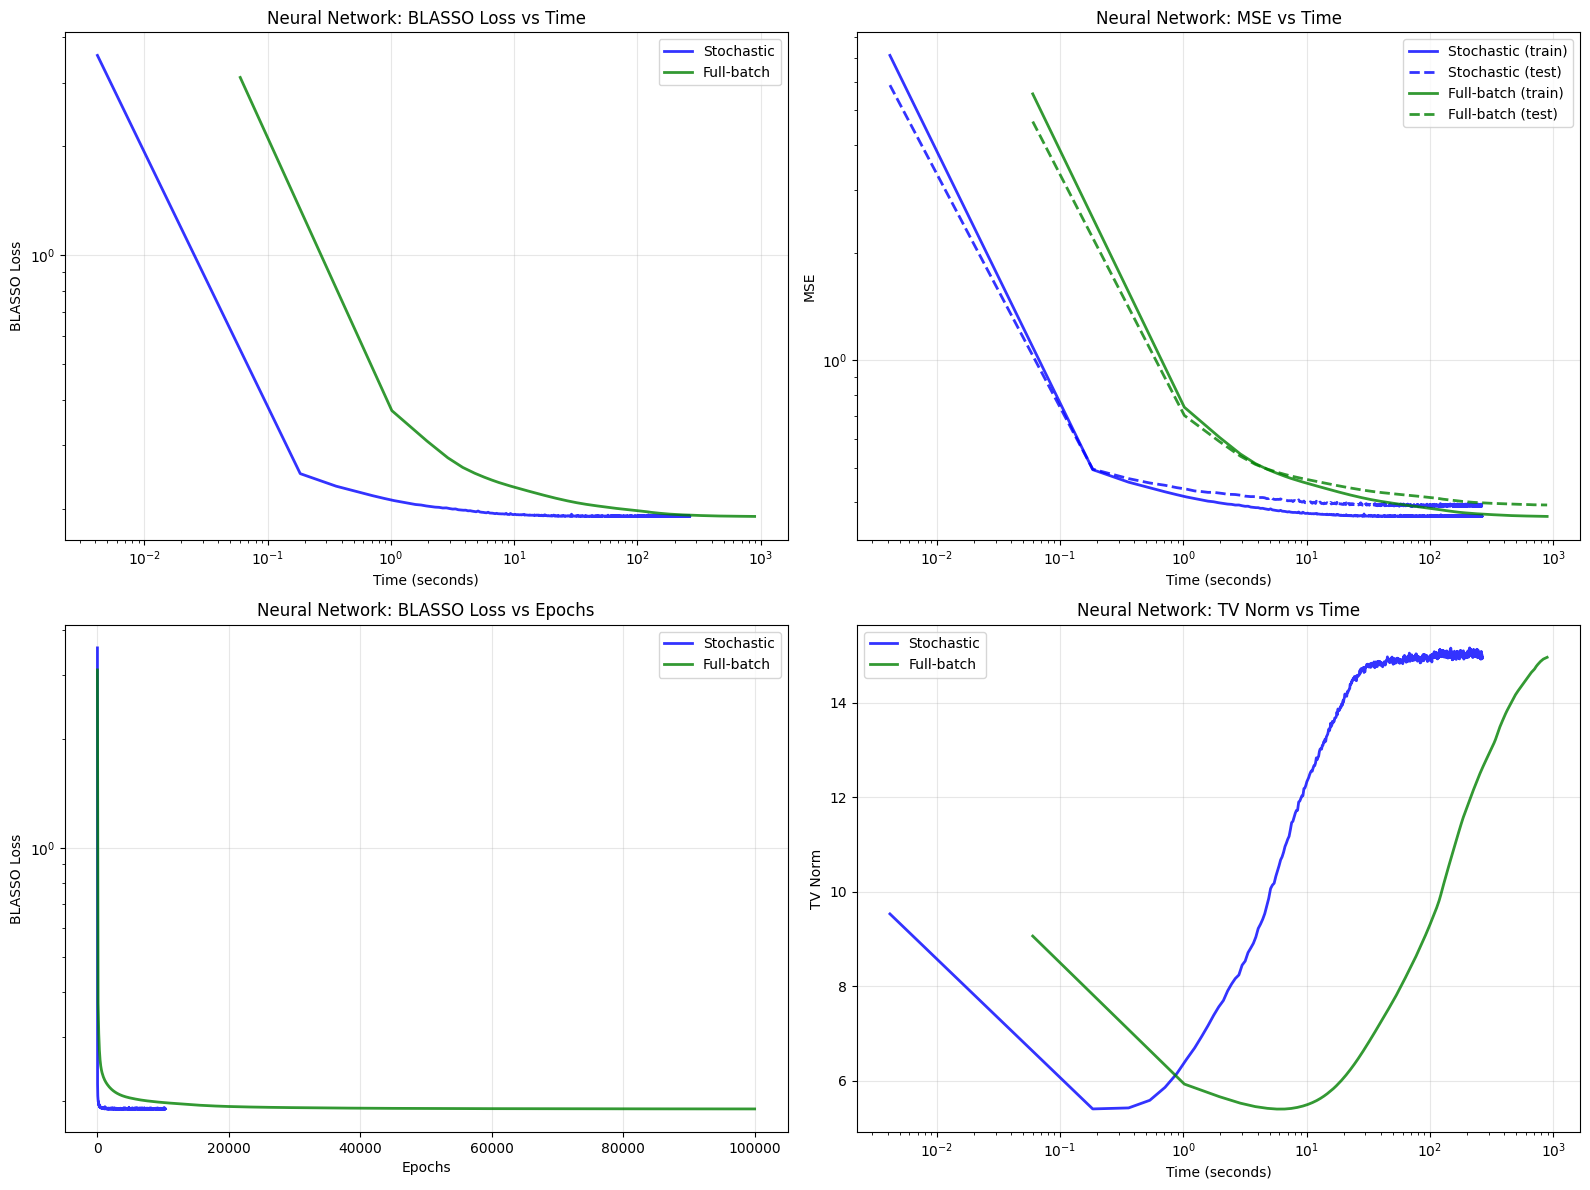


Final Results:
Stochastic:
  MSE (train): 0.366231
  MSE (test):  0.393154
  TV norm:     14.9533
  Time:        265.10s

Full-batch:
  MSE (train): 0.365476
  MSE (test):  0.393433
  TV norm:     14.9645
  Time:        892.18s

Speedup: 3.37x


In [11]:
# Convert iterations to epochs
nn_epochs_stochastic = [it * NN_BATCH_SIZE / len(X_train_tensor) for it in nn_iterations]
nn_epochs_full_batch = [it for it in nn_iterations_full_batch]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss vs Time (BLASSO loss)
ax = axes[0, 0]
ax.plot(nn_times, nn_losses_full, linewidth=2, label='Stochastic', alpha=0.8, color='blue')
ax.plot(nn_times_full_batch, nn_losses_full_batch, 
        linewidth=2, label='Full-batch', alpha=0.8, color='green')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('BLASSO Loss')
ax.set_title('Neural Network: BLASSO Loss vs Time')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.set_xscale('log')

# Plot 2: MSE Train vs Time
ax = axes[0, 1]
ax.plot(nn_times, nn_mse_train, linewidth=2, label='Stochastic (train)', alpha=0.8, color='blue')
ax.plot(nn_times, nn_mse_test, linewidth=2, label='Stochastic (test)', 
        alpha=0.8, color='blue', linestyle='--')
ax.plot(nn_times_full_batch, nn_mse_train_full_batch, 
        linewidth=2, label='Full-batch (train)', alpha=0.8, color='green')
ax.plot(nn_times_full_batch, nn_mse_test_full_batch, 
        linewidth=2, label='Full-batch (test)', alpha=0.8, color='green', linestyle='--')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('MSE')
ax.set_title('Neural Network: MSE vs Time')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.set_xscale('log')

# Plot 3: Loss vs Epochs
ax = axes[1, 0]
ax.plot(nn_epochs_stochastic, nn_losses_full, linewidth=2, label='Stochastic', alpha=0.8, color='blue')
ax.plot(nn_epochs_full_batch, nn_losses_full_batch, 
        linewidth=2, label='Full-batch', alpha=0.8, color='green')
ax.set_xlabel('Epochs')
ax.set_ylabel('BLASSO Loss')
ax.set_title('Neural Network: BLASSO Loss vs Epochs')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')


# Plot 4: TV Norm vs Time
ax = axes[1, 1]
ax.plot(nn_times, nn_tv_norms, linewidth=2, label='Stochastic', alpha=0.8, color='blue')
ax.plot(nn_times_full_batch, nn_tv_norms_full_batch, 
        linewidth=2, label='Full-batch', alpha=0.8, color='green')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('TV Norm')
ax.set_title('Neural Network: TV Norm vs Time')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

print("\nFinal Results:")
print(f"Stochastic:")
print(f"  MSE (train): {nn_mse_train[-1]:.6f}")
print(f"  MSE (test):  {nn_mse_test[-1]:.6f}")
print(f"  TV norm:     {nn_tv_norms[-1]:.4f}")
print(f"  Time:        {nn_times[-1]:.2f}s")
print(f"\nFull-batch:")
print(f"  MSE (train): {nn_mse_train_full_batch[-1]:.6f}")
print(f"  MSE (test):  {nn_mse_test_full_batch[-1]:.6f}")
print(f"  TV norm:     {nn_tv_norms_full_batch[-1]:.4f}")
print(f"  Time:        {nn_times_full_batch[-1]:.2f}s")
print(f"\nSpeedup: {nn_times_full_batch[-1] / nn_times[-1]:.2f}x")

## 9. Weight Distribution & Sparsity Analysis

A key feature of BLASSO/FastPart is the **automatic promotion of sparse solutions**.
The TV-norm penalty $\lambda\|\nu\|_{\mathrm{TV}} = \lambda\sum_i \omega_i$
acts as a continuous relaxation of counting non-zero neurons,
analogous to $\ell^1$-regularisation in high-dimensional statistics.

**Result (representer theorem, Boyer et al. 2019, §4):** If $\Phi$ has finite rank $m$,
the BLASSO admits a solution with at most $m$ atoms.
Here the TV regularisation forces far fewer than $p = 100$ active neurons.

We count **active neurons** at different amplitude thresholds
$\{0.001, 0.01, 0.1, 0.5\}$ and compare the sparsity patterns
between Stochastic CPGD and Full-Batch CPGD.


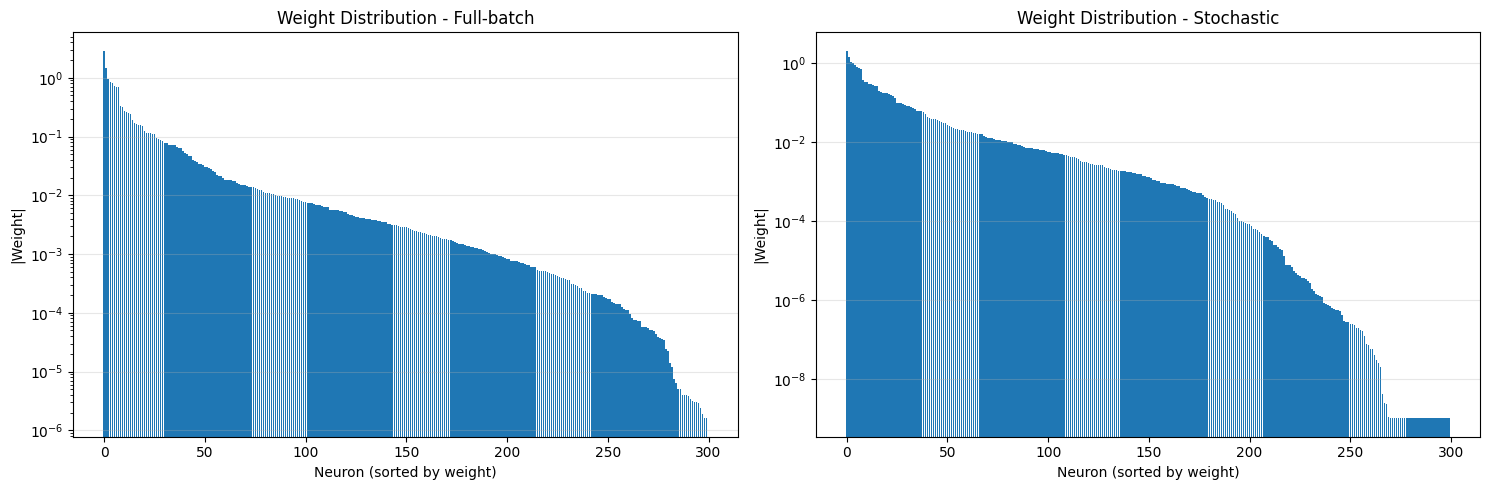

Sparsity analysis for Neural Network:

Total number of neurons: 300

Full-batch:
  Threshold 0.001: 194 active neurons (64.7%)
  Threshold 0.01: 86 active neurons (28.7%)
  Threshold 0.1: 26 active neurons (8.7%)
  Threshold 0.5: 8 active neurons (2.7%)

Stochastic:
  Threshold 0.001: 156 active neurons (52.0%)
  Threshold 0.01: 81 active neurons (27.0%)
  Threshold 0.1: 25 active neurons (8.3%)
  Threshold 0.5: 8 active neurons (2.7%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Full-batch
ax = axes[0]
nn_weights_full = nn_particles_full.amplitudes.detach().numpy()
ax.bar(range(len(nn_weights_full)), sorted(np.abs(nn_weights_full), reverse=True))
ax.set_xlabel('Neuron (sorted by weight)')
ax.set_ylabel('|Weight|')
ax.set_title('Weight Distribution - Full-batch')
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')

# Stochastic
ax = axes[1]
nn_weights_stoch = nn_particles.amplitudes.detach().numpy()
ax.bar(range(len(nn_weights_stoch)), sorted(np.abs(nn_weights_stoch), reverse=True))
ax.set_xlabel('Neuron (sorted by weight)')
ax.set_ylabel('|Weight|')
ax.set_title('Weight Distribution - Stochastic')
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Count active neurons
def count_active_neurons(particles: Particles, thresholds: list[float]) -> dict:
    """Count active neurons for different thresholds."""
    with torch.no_grad():
        amplitudes = particles.amplitudes.abs()
        counts = {}
        for threshold in thresholds:
            n_active = (amplitudes > threshold).sum().item()
            counts[threshold] = n_active
        return counts

thresholds_nn = [0.001, 0.01, 0.1, 0.5]

print("Sparsity analysis for Neural Network:\n")
print(f"Total number of neurons: {NN_N_PARTICLES}\n")

print("Full-batch:")
counts_full_nn = count_active_neurons(nn_particles_full, thresholds_nn)
for threshold, count in counts_full_nn.items():
    print(f"  Threshold {threshold}: {count} active neurons ({count/NN_N_PARTICLES*100:.1f}%)")

print("\nStochastic:")
counts_stoch_nn = count_active_neurons(nn_particles, thresholds_nn)
for threshold, count in counts_stoch_nn.items():
    print(f"  Threshold {threshold}: {count} active neurons ({count/NN_N_PARTICLES*100:.1f}%)")


## 10. Experiment Summary

The cell below prints a complete quantitative summary of the experiment:

- **Final train/test MSE** for both Stochastic CPGD and Full-Batch CPGD
- **Final TV norm** $\|\nu\|_{\mathrm{TV}}$ (proxy for model complexity)
- **Sparsity** (number of active neurons above amplitude thresholds)
- **Wall-clock speedup** of FastPart over full-batch CPGD

**Key observations:**

1. FastPart achieves comparable generalisation error in **shorter wall time**.
2. Sparse representation: few dominant neurons emerge (representer theorem).
3. The TV norm remains bounded throughout training.
4. The $\mathcal{O}(\log K / \sqrt{K})$ convergence rate is visible in the loss curves.


In [13]:
print("=" * 80)
print("NEURAL NETWORK EXPERIMENT SUMMARY")
print("=" * 80)
print(f"\nDataset: California Housing")
print(f"  - Features (d): {NN_INPUT_DIM}")
print(f"  - Training samples: {len(X_train_tensor)}")
print(f"  - Test samples: {len(X_test_tensor)}")
print(f"\nArchitecture: Two-layer NN with affine ReLU neurons")
print(f"  - Feature map: phi_theta(x) = ReLU(<w, x> + b), theta=(w,b) in R^{NN_THETA_DIM}")
print(f"  - Hidden layer size (particles): {NN_N_PARTICLES}")
print(f"  - Positions projected onto unit ball in R^{NN_THETA_DIM}")
print(f"\nHyperparameters:")
print(f"  - Regularization (kappa): {NN_KAPPA}")
print(f"  - Learning rate positions (eta): {NN_ETA}")
print(f"  - Learning rate weights (eta_w): {NN_ETA_W}")
print(f"  - Batch size (stochastic): {NN_BATCH_SIZE}")
print(f"  - Batch size (full-batch): {len(X_train_tensor)}")
print(f"  - Optimizer: CPGD (signed mirror descent, no Adagrad)")
print(f"  - Position update: eps_i * Euclidean gradient + unit ball projection")
print(f"\nResults - Stochastic CPGD:")
print(f"  - Final MSE (train): {nn_mse_train[-1]:.6f}")
print(f"  - Final MSE (test):  {nn_mse_test[-1]:.6f}")
print(f"  - Final TV norm: {nn_tv_norms[-1]:.4f}")
print(f"  - Training time: {nn_times[-1]:.2f}s")
print(f"  - Iterations: {nn_iterations[-1]}")
print(f"  - Active neurons (>0.01): {counts_stoch_nn[0.01]}/{NN_N_PARTICLES}")
print(f"\nResults - Full-batch CPGD:")
print(f"  - Final MSE (train): {nn_mse_train_full_batch[-1]:.6f}")
print(f"  - Final MSE (test):  {nn_mse_test_full_batch[-1]:.6f}")
print(f"  - Final TV norm: {nn_tv_norms_full_batch[-1]:.4f}")
print(f"  - Training time: {nn_times_full_batch[-1]:.2f}s")
print(f"  - Iterations: {nn_iterations_full_batch[-1]}")
print(f"  - Active neurons (>0.01): {counts_full_nn[0.01]}/{NN_N_PARTICLES}")
print("\n" + "=" * 80)


NEURAL NETWORK EXPERIMENT SUMMARY

Dataset: California Housing
  - Features (d): 8
  - Training samples: 18576
  - Test samples: 2064

Architecture: Two-layer NN with affine ReLU neurons
  - Feature map: phi_theta(x) = ReLU(<w, x> + b), theta=(w,b) in R^9
  - Hidden layer size (particles): 300
  - Positions projected onto unit ball in R^9

Hyperparameters:
  - Regularization (kappa): 0.0005
  - Learning rate positions (eta): 0.01
  - Learning rate weights (eta_w): 0.1
  - Batch size (stochastic): 256
  - Batch size (full-batch): 18576
  - Optimizer: CPGD (signed mirror descent, no Adagrad)
  - Position update: eps_i * Euclidean gradient + unit ball projection

Results - Stochastic CPGD:
  - Final MSE (train): 0.366231
  - Final MSE (test):  0.393154
  - Final TV norm: 14.9533
  - Training time: 265.10s
  - Iterations: 749999
  - Active neurons (>0.01): 81/300

Results - Full-batch CPGD:
  - Final MSE (train): 0.365476
  - Final MSE (test):  0.393433
  - Final TV norm: 14.9645
  - Train

## 11. Birth–Death Process

### Motivation

The BLASSO regularisation automatically **pushes small particles toward zero**, but it does not remove genuinely useless neurons nor inject new ones in regions not covered by the initial cloud.  A **birth–death** mechanism makes the particle cloud adaptive:

* **Death** — *de-activation of redundant particles.*  At regular intervals (with an initial delay), the particle $i^*$ whose Fréchet sub-optimality score exceeds a threshold is **removed**.

  The sub-optimality score for particle $i$ is

  $$
  s_i := \frac{\varepsilon_i \, 2\, J'_\nu(\vartheta_i)}{\omega_i\mathbb{K}(\vartheta_i, \vartheta_i)}
  $$

  Here $J'_\nu$ is the Fréchet differential computed in the code (`ev.Jp`) and the paper's $J_p(\vartheta_i) = \varepsilon_i \, J'_\nu(\vartheta_i)$ (Section 4 of the paper is written for non-negative measures, hence $\varepsilon_i = 1$ there; in our signed-measure code the correction factor $\varepsilon_i$ restores the correct sign).

  At a critical point, $J'_\nu(\vartheta_i) = 0$ for all active particles, so $s_i = 0$.  A large positive $s_i$ signals that the particle is far from stationarity relative to its weight and self-kernel $\mathbb{K}(\vartheta_i,\vartheta_i)$, and should be killed.  The factor $2$ and the $\mathbb{K}(\vartheta_i,\vartheta_i)$ term arise from the exact second-order Taylor expansion of $J$ between $J(\nu)$ and $J(\nu - \omega_i\,\delta_{\vartheta_i})$.

  **Death rule:** remove $i^* = \arg\max_i s_i$ if $s_{i^*} > \tau_{\mathrm{death}}$, with $\tau_{\mathrm{death}} = 2$ (theoretical lower bound is $1$).

* **Birth** — *injection of a new particle in a promising region.*  At regular intervals, $n_{\mathrm{test}}$ positions $\vartheta^{(k)}$ are sampled uniformly on the unit sphere $\mathbb{S}^{d}$.  The Fréchet differential $J'_\nu(\vartheta^{(k)})$ is evaluated at each test point.  A new particle is **born** if the most-negative value satisfies the decision rule

  $$
  \min_k J'_\nu(\vartheta^{(k)}) < \tau_{\mathrm{birth}} \sqrt{\frac{d\,\log(\mathrm{batchsize})}{{\mathrm{batchsize}}}}
  $$

  The threshold adapts to the noise level of the Fréchet oracle:
  - **Full-batch** ($\tau_{\mathrm{birth}} = -1$): the oracle is exact, so the threshold $-\sqrt{d\log N/N}$ is *negative* — birth fires only on genuine KKT violations $J'_\nu < 0$.
  - **Stochastic** ($\tau_{\mathrm{birth}} = 5$): the threshold $5\sqrt{d\log B/B}$ is *positive* — it accounts for the typical fluctuation amplitude of the stochastic estimator.

  **Birth rule:** add a particle at $\hat\vartheta = \arg\min_k J'_\nu(\vartheta^{(k)})$ (with $\varepsilon_{\mathrm{new}} = +1$) whenever the decision rule above is satisfied.

  **Birth weight:** the initial amplitude is set to
  $$
  \omega_{\mathrm{new}} = \frac{|J'_\nu(\hat\vartheta)|}{\mathbb{K}(\hat\vartheta,\,\hat\vartheta)},
  $$
  where $\mathbb{K}(\hat\vartheta,\hat\vartheta) = \frac{1}{N}\sum_k \varphi_{\hat\vartheta}(x_k)^2$ is the self-kernel.  This choice arises from the second-order Taylor expansion of $J$ and guarantees the new particle immediately reduces the objective (theoretical upper bound is twice this value).

### Hyperparameters

| Quantity | Full-batch | Stochastic |
|---|---|---|
| Death delay | 15 000 steps | 100 000 steps |
| Death every | 500 steps | 1 500 steps |
| Birth delay | 2 000 steps | 50 000 steps |
| Birth every | 1 000 steps | 5 000 steps |
| Test points per birth check | 1 000 | 1 000 |
| $\tau_{\mathrm{death}}$ | $2$ | $2$ |
| $\tau_{\mathrm{birth}}$ | $-1$ | $5$ |
| Birth threshold | $-\sqrt{d\log N/N}$ | $5\sqrt{d\log B/B}$ |


In [14]:

# ============================================================================
# BIRTH–DEATH UTILITY FUNCTIONS
# ============================================================================

def bd_remove_particle(particles: Particles, idx: int) -> Particles:
    """Return a new Particles with particle `idx` removed."""
    n = len(particles)
    keep = [i for i in range(n) if i != idx]
    with torch.no_grad():
        new_pos    = particles.positions.data[keep].clone()
        new_w      = particles.weights.data[keep].clone()
        new_signs  = particles.signs[keep].clone()
    return Particles(particles.h, new_pos, new_w, new_signs)


def bd_add_particle(particles: Particles,
                    new_position: Tensor,
                    new_weight: float,
                    new_sign: float) -> Particles:
    """Return a new Particles with one extra particle appended."""
    with torch.no_grad():
        new_pos   = torch.cat([particles.positions.data,
                                new_position.unsqueeze(0)], dim=0)
        new_w     = torch.cat([particles.weights.data,
                                torch.tensor([new_weight])], dim=0)
        new_signs = torch.cat([particles.signs,
                                torch.tensor([new_sign])], dim=0)
    return Particles(particles.h, new_pos, new_w, new_signs)


def death_step(particles: Particles,
               problem: NNBlasso,
               threshold: float) -> tuple:
    """
    Death criterion based on the second-order Taylor expansion of J:

        s_i = 2 * eps_i * J'_nu(vartheta_i) / (omega_i * K(vartheta_i, vartheta_i))

    This score arises from the exact Taylor expansion of order two of J between
    J(nu) and J(nu - omega_i * delta_{vartheta_i}).  At a critical point,
    J'_nu(vartheta_i) = 0, so s_i = 0.  A large positive s_i signals that the
    particle is far from stationarity relative to its weight and self-kernel,
    and should be removed.  Theoretical lower bound for tau_death is 1;
    we use tau_death = 2 in practice.

    Remove the particle with the highest s_i if s_i > threshold.

    Returns (new_particles, removed: bool, idx_removed: int or -1).
    """
    with torch.no_grad():
        ev      = problem(particles)
        # Self-kernel: K(theta_i, theta_i) = (1/n) sum_k phi_i(x_k)^2
        K_diag  = ev.phi.pow(2).sum(dim=1) / ev.phi.shape[1]                           # (p,)
        # s_i = 2 * eps_i * J'_nu(theta_i) / (omega_i * K(theta_i, theta_i))
        scores  = 2.0 * particles.signs * ev.Jp / (particles.weights * K_diag.clamp(min=1e-10))  # (p,)
        max_val, max_idx = scores.max(dim=0)

        if max_val.item() > threshold:
            idx = max_idx.item()
            return bd_remove_particle(particles, idx), True, idx

    return particles, False, -1


def birth_step(particles: Particles,
               problem: NNBlasso,
               n_test: int,
               threshold: float,
               theta_dim: int) -> tuple:
    """
    Birth criterion for the NON-NEGATIVE BLASSO (all eps_i = +1).

    KKT feasibility requires J'_nu(theta) >= 0 for all theta.
    A violation at some test point means that adding a positive-measure
    particle (eps_new = +1) there strictly decreases the BLASSO objective.

    Decision rule (stochastic oracle threshold):
      - Sample n_test positions uniformly on the unit sphere S^{theta_dim-1}.
      - Evaluate J'_nu (= Jp_code) at each test point.
      - threshold = tau_birth * sqrt(d * log(batchsize) / batchsize)
        with tau_birth = 5.  For full-batch, batchsize = N; for stochastic,
        batchsize = B.
      - If min(Jp_code) < threshold: add particle at argmin with eps_new = +1.

    There is no case where eps_new = -1 should be used, since the measure
    is constrained to be non-negative throughout the dynamic.

    Birth weight (from the 2nd-order Taylor expansion of J):
        omega_new = |J'_nu(vartheta_new)| / K(vartheta_new, vartheta_new)
    where K(vartheta_new, vartheta_new) = (1/n) sum_k phi_new(x_k)^2.
    The theoretical upper bound is twice this value; we use the lower value here.

    Returns (new_particles, born: bool, Jp_code_at_new: float).
    """
    with torch.no_grad():
        # ---- Sample test positions on unit sphere ----
        test_pos = torch.randn(n_test, theta_dim)
        test_pos = test_pos / test_pos.norm(dim=1, keepdim=True)

        # ---- Evaluate Jp at test positions ----------------------
        # phi_test[k, s] = ReLU(<w_k, x_s> + b_k)
        w_test   = test_pos[:, :-1]   # (n_test, d)
        b_test   = test_pos[:, -1:]   # (n_test, 1)
        phi_test = torch.relu(w_test @ problem.inputs.T + b_test)

        # Current signed amplitudes
        ev_curr   = problem(particles)
        a_signed  = particles.amplitudes * particles.signs         # (p,)
        phi_curr  = ev_curr.phi                                    # (p, n_samples)
        n_samples = phi_curr.shape[1]

        # Kernel between test point k and current particle j
        K_test = phi_test @ phi_curr.T / n_samples                 # (n_test, p)
        # Scalar product k_y(theta_test)
        sp_test = (phi_test @ problem.y).squeeze() / n_samples     # (n_test,)
        # J'_nu at test positions
        Jp_test = problem.kappa + K_test @ a_signed - sp_test      # (n_test,)

        # Birth decision rule:
        #   min_k J'_nu(vartheta^(k)) < threshold
        # where threshold = tau_birth * sqrt(d * log(batchsize) / batchsize).
        min_val, min_idx = Jp_test.min(dim=0)

        if min_val.item() < threshold:
            new_pos   = test_pos[min_idx.item()]
            # omega_new = |J'_nu(vartheta_new)| / K(vartheta_new, vartheta_new)
            # K(vartheta_new, vartheta_new) = (1/n) sum_k phi_new(x_k)^2
            phi_new    = phi_test[min_idx.item()]                      # (n_samples,)
            K_self_new = phi_new.pow(2).sum() / n_samples              # scalar
            init_weight = (min_val.clamp(max=1).abs() / K_self_new.clamp(min=1e-3)).item()
            return bd_add_particle(particles, new_pos, init_weight, +1.0), \
                   True, min_val.item()

    return particles, False, 0.0


print("✓ Birth–death utility functions defined!")
print(f"  Death score  : s_i = 2 * eps_i * J'_nu(theta_i) / (omega_i * K(theta_i, theta_i))")
print(f"  Birth rule   : min_k J'_nu(vartheta^(k)) < tau_birth * sqrt(d * log(B) / B),  tau_birth=5")
print(f"  Birth weight : omega_new = |J'_nu(theta_new)| / K(theta_new, theta_new)")


✓ Birth–death utility functions defined!
  Death score  : s_i = 2 * eps_i * J'_nu(theta_i) / (omega_i * K(theta_i, theta_i))
  Birth rule   : min_k J'_nu(vartheta^(k)) < tau_birth * sqrt(d * log(B) / B),  tau_birth=5
  Birth weight : omega_new = |J'_nu(theta_new)| / K(theta_new, theta_new)


### Full-Batch CPGD with Birth–Death

Same hyper-parameters as in Section 5 but with the adaptive particle count.
Death is checked every **500 steps** after a delay of **15 000 steps**;
birth is tested every **1 000 steps** after a delay of **2 000 steps**, against **1 000** random candidate
positions on the unit sphere.


In [15]:
# Birth–Death schedule (full-batch)
BD_FULL_DEATH_DELAY  = 5000    # steps before first death check
BD_FULL_DEATH_EVERY  = 500      # death checked every N steps
BD_FULL_BIRTH_EVERY  = 1000     #5000      # birth tested every N steps
BD_FULL_BIRTH_DELAY  = 2500     # steps before first birth check  <- mirrors death logic
BD_FULL_N_TEST       = 1000              # number of random candidate positions for birth
BD_THRESHOLD_DEATH   = 5                   # tau_death (theoretical lower bound: 1)
# tau_birth * sqrt(d * log(N) / N),  tau_birth = 5,  N = full training set size
_TAU_BIRTH           = -1 
BD_THRESHOLD_BIRTH   = _TAU_BIRTH * np.sqrt(NN_THETA_DIM * np.log(len(X_train_tensor)) / len(X_train_tensor))

# NN_N_ITERATIONS_FULL = 25000

# Independent particle + optimizer initialisation (same seed as §7 for fair comparison)
nn_particles_full_bd = initialize_nn_particles(
    n_particles=NN_N_PARTICLES,
    theta_dim=NN_THETA_DIM,
    seed=314
)

def make_full_optimizer(particles: Particles) -> NNOptimizer:
    return NNOptimizer(
        particles=particles,
        problem=nn_problem,
        eta=NN_ETA,
        eta_w=NN_ETA_W
    )

nn_opt_full_bd = make_full_optimizer(nn_particles_full_bd)

# Storage
bd_full_losses      = []
bd_full_mse_train   = []
bd_full_mse_test    = []
bd_full_tv_norms    = []
bd_full_n_particles = []
bd_full_iters       = []
bd_full_times       = []
bd_full_deaths      = []   # (step, n_particles_after)
bd_full_births      = []   # (step, n_particles_after)

print("Training Full-Batch CPGD + Birth–Death …")
print(f"  death every {BD_FULL_DEATH_EVERY} steps (delay {BD_FULL_DEATH_DELAY}) | "
      f"tau_death = {BD_THRESHOLD_DEATH:.4f}")
print(f"  birth every {BD_FULL_BIRTH_EVERY} steps (delay {BD_FULL_BIRTH_DELAY}) "
      f"| tau_birth= {BD_THRESHOLD_BIRTH:.6f}  "
      f"(= -1*sqrt({NN_THETA_DIM}*log({len(X_train_tensor)})/{len(X_train_tensor)}))\n")

start_bd_full = time.time()

for iteration in range(NN_N_ITERATIONS_FULL):
    particles = nn_opt_full_bd.particles

    # ---- Standard CPGD step ----
    nn_opt_full_bd.zero_grad()
    loss_train = nn_opt_full_bd.step()

    # ---- Death ----
    if (iteration >= BD_FULL_DEATH_DELAY
            and iteration % BD_FULL_DEATH_EVERY == 0
            and len(particles) > 1):
        new_p, died, idx = death_step(
            particles, nn_problem, BD_THRESHOLD_DEATH)
        if died:
            nn_opt_full_bd = make_full_optimizer(new_p)
            bd_full_deaths.append((iteration, len(new_p)))

    # ---- Birth ----
    # NOTE: delay guard needed – 0 % N == 0 always, so without
    # this guard a spurious birth fires at iteration 0.
    if (iteration >= BD_FULL_BIRTH_DELAY
            and iteration % BD_FULL_BIRTH_EVERY == 0):
        particles = nn_opt_full_bd.particles
        new_p, born, jp_val = birth_step(
            particles, nn_problem,
            BD_FULL_N_TEST, BD_THRESHOLD_BIRTH, NN_THETA_DIM)
        if born:
            nn_opt_full_bd = make_full_optimizer(new_p)
            bd_full_births.append((iteration, len(new_p)))

    # ---- Logging ----
    if iteration % (NN_LOG_INTERVAL // 5) == 0 or iteration == NN_N_ITERATIONS_FULL - 1:
        p = nn_opt_full_bd.particles
        with torch.no_grad():
            ev_train = nn_problem(p)
            mse_tr   = ev_train.proximity.item() * 2
            tv_n     = p.tv_norm().item()
            ev_test  = nn_problem_test(p)
            mse_te   = ev_test.proximity.item() * 2

            bd_full_losses.append(loss_train)
            bd_full_mse_train.append(mse_tr)
            bd_full_mse_test.append(mse_te)
            bd_full_tv_norms.append(tv_n)
            bd_full_n_particles.append(len(p))
            bd_full_iters.append(iteration)
            bd_full_times.append(time.time() - start_bd_full)

            print(f"Iter {iteration:5d} | Loss: {loss_train:.6f} | "
                  f"MSE(train): {mse_tr:.6f} | MSE(test): {mse_te:.6f} | "
                  f"TV: {tv_n:.4f} | particles: {len(p)}")

print(f"\nFull-BD training done. Time: {bd_full_times[-1]:.2f}s | "
      f"Deaths: {len(bd_full_deaths)} | Births: {len(bd_full_births)}")


Training Full-Batch CPGD + Birth–Death …
  death every 500 steps (delay 5000) | tau_death = 5.0000
  birth every 1000 steps (delay 2500) | tau_birth= -0.069010  (= -1*sqrt(9*log(18576)/18576))

Iter     0 | Loss: 3.101026 | MSE(train): 5.560418 | MSE(test): 4.652818 | TV: 9.0643 | particles: 300
Iter   100 | Loss: 0.372780 | MSE(train): 0.738566 | MSE(test): 0.700564 | TV: 5.9311 | particles: 300
Iter   200 | Loss: 0.307266 | MSE(train): 0.608427 | MSE(test): 0.592042 | TV: 5.6640 | particles: 300
Iter   300 | Loss: 0.276146 | MSE(train): 0.546539 | MSE(test): 0.538882 | TV: 5.5269 | particles: 300
Iter   400 | Loss: 0.259755 | MSE(train): 0.513921 | MSE(test): 0.511265 | TV: 5.4543 | particles: 300
Iter   500 | Loss: 0.250242 | MSE(train): 0.494980 | MSE(test): 0.495803 | TV: 5.4174 | particles: 300
Iter   600 | Loss: 0.244050 | MSE(train): 0.482632 | MSE(test): 0.486061 | TV: 5.4022 | particles: 300
Iter   700 | Loss: 0.239551 | MSE(train): 0.473646 | MSE(test): 0.479216 | TV: 5.4029

### Stochastic CPGD (FastPart) with Birth–Death

Compared to the full-batch BD schedule, the delays and periods are scaled up
to account for the much larger number of stochastic steps:
death is checked every **1 500 steps** after a delay of **100 000 steps**;
birth is tested every **5 000 steps** after a delay of **50 000 steps**.
The Fréchet differential for the birth check is computed on the **full training set**
(not the mini-batch) to get a reliable signal.


In [16]:
# Birth–Death schedule (stochastic / FastPart)
BD_STO_DEATH_DELAY  = 25000    # steps before first death check
BD_STO_DEATH_EVERY  = 1000     # death checked every N steps
BD_STO_BIRTH_EVERY  = 25000     # birth tested every N steps
BD_STO_BIRTH_DELAY  = 10000     # steps before first birth check  <- mirrors death logic
BD_STO_N_TEST       = 1000     # random candidate positions for birth check
# tau_birth * sqrt(d * log(B) / B),  tau_birth = 2,  B = mini-batch size
BD_STO_THRESHOLD_BIRTH = 2 * np.sqrt(NN_THETA_DIM * np.log(NN_BATCH_SIZE) / NN_BATCH_SIZE)

NN_N_ITERATIONS_STO = NN_N_ITERATIONS
# Death threshold reused from full-batch (BD_THRESHOLD_DEATH); birth threshold is batch-specific.

# Independent particle + optimizer initialisation (same seed as §6)
nn_particles_sto_bd = initialize_nn_particles(
    n_particles=NN_N_PARTICLES,
    theta_dim=NN_THETA_DIM,
    seed=314
)

def make_sto_optimizer(particles: Particles) -> StochasticNNOptimizer:
    return StochasticNNOptimizer(
        particles=particles,
        problem=nn_problem,
        eta=NN_ETA,
        eta_w=NN_ETA_W,
        batch_size=NN_BATCH_SIZE
    )

nn_opt_sto_bd = make_sto_optimizer(nn_particles_sto_bd)

# Storage
bd_sto_losses_batch  = []
bd_sto_losses_full   = []
bd_sto_mse_train     = []
bd_sto_mse_test      = []
bd_sto_tv_norms      = []
bd_sto_n_particles   = []
bd_sto_iters         = []
bd_sto_times         = []
bd_sto_deaths        = []   # (step, n_particles_after)
bd_sto_births        = []   # (step, n_particles_after)

print("Training Stochastic CPGD (FastPart) + Birth–Death …")
print(f"  Iterations: {NN_N_ITERATIONS_STO} | BS: {NN_BATCH_SIZE}")
print(f"  death every {BD_STO_DEATH_EVERY} steps (delay {BD_STO_DEATH_DELAY}) | "
      f"tau_death = {BD_THRESHOLD_DEATH:.4f}")
print(f"  birth every {BD_STO_BIRTH_EVERY} steps (delay {BD_STO_BIRTH_DELAY}) "
      f"| tau_birth=5, threshold = {BD_STO_THRESHOLD_BIRTH:.6f}  "
      f"(= 5*sqrt({NN_THETA_DIM}*log({NN_BATCH_SIZE})/{NN_BATCH_SIZE}))\n")

start_bd_sto = time.time()

for iteration in range(NN_N_ITERATIONS_STO):
    particles = nn_opt_sto_bd.particles

    # ---- Stochastic CPGD step ----
    nn_opt_sto_bd.zero_grad()
    loss_batch = nn_opt_sto_bd.step()

    # ---- Death (uses full problem to get reliable Jp) ----
    if (iteration >= BD_STO_DEATH_DELAY
            and iteration % BD_STO_DEATH_EVERY == 0
            and len(particles) > 1):
        new_p, died, idx = death_step(
            particles, nn_problem, BD_THRESHOLD_DEATH)
        if died:
            nn_opt_sto_bd = make_sto_optimizer(new_p)
            bd_sto_deaths.append((iteration, len(new_p)))

    # ---- Birth (uses full problem for reliable Jp evaluation) ----
    # NOTE: delay guard needed – 0 % N == 0 always, so without
    # this guard a spurious birth fires at iteration 0.
    if (iteration >= BD_STO_BIRTH_DELAY
            and iteration % BD_STO_BIRTH_EVERY == 0):
        particles = nn_opt_sto_bd.particles
        new_p, born, jp_val = birth_step(
            particles, nn_problem,
            BD_STO_N_TEST, BD_STO_THRESHOLD_BIRTH, NN_THETA_DIM)
        if born:
            nn_opt_sto_bd = make_sto_optimizer(new_p)
            bd_sto_births.append((iteration, len(new_p)))

    # ---- Logging ----
    if iteration % NN_LOG_INTERVAL == 0 or iteration == NN_N_ITERATIONS_STO - 1:
        p = nn_opt_sto_bd.particles
        with torch.no_grad():
            ev_train = nn_problem(p)
            loss_tr  = ev_train.loss.item()
            mse_tr   = ev_train.proximity.item() * 2
            tv_n     = p.tv_norm().item()
            ev_test  = nn_problem_test(p)
            mse_te   = ev_test.proximity.item() * 2

            bd_sto_losses_batch.append(loss_batch)
            bd_sto_losses_full.append(loss_tr)
            bd_sto_mse_train.append(mse_tr)
            bd_sto_mse_test.append(mse_te)
            bd_sto_tv_norms.append(tv_n)
            bd_sto_n_particles.append(len(p))
            bd_sto_iters.append(iteration)
            bd_sto_times.append(time.time() - start_bd_sto)

            print(f"Iter {iteration:6d} | Loss: {loss_tr:.6f} | "
                  f"MSE(train): {mse_tr:.6f} | MSE(test): {mse_te:.6f} | "
                  f"TV: {tv_n:.4f} | particles: {len(p)}")

print(f"\nStochastic-BD training done. Time: {bd_sto_times[-1]:.2f}s | "
      f"Deaths: {len(bd_sto_deaths)} | Births: {len(bd_sto_births)}")


Training Stochastic CPGD (FastPart) + Birth–Death …
  Iterations: 750000 | BS: 256
  death every 1000 steps (delay 25000) | tau_death = 5.0000
  birth every 25000 steps (delay 10000) | tau_birth=5, threshold = 0.883058  (= 5*sqrt(9*log(256)/256))

Iter      0 | Loss: 3.567508 | MSE(train): 7.125482 | MSE(test): 5.882306 | TV: 9.5332 | particles: 300
Iter    500 | Loss: 0.249704 | MSE(train): 0.494003 | MSE(test): 0.495584 | TV: 5.4051 | particles: 300
Iter   1000 | Loss: 0.230565 | MSE(train): 0.455703 | MSE(test): 0.466341 | TV: 5.4263 | particles: 300
Iter   1500 | Loss: 0.222585 | MSE(train): 0.439582 | MSE(test): 0.453315 | TV: 5.5880 | particles: 300
Iter   2000 | Loss: 0.217069 | MSE(train): 0.428277 | MSE(test): 0.446667 | TV: 5.8617 | particles: 300
Iter   2500 | Loss: 0.213253 | MSE(train): 0.420352 | MSE(test): 0.439876 | TV: 6.1534 | particles: 300
Iter   3000 | Loss: 0.210381 | MSE(train): 0.414308 | MSE(test): 0.435668 | TV: 6.4545 | particles: 300
Iter   3500 | Loss: 0.20

### 12. Four-way Comparison: Standard vs Birth–Death (Batch and Stochastic)

We plot six panels:
1. **BLASSO loss vs wall-clock time** — all four variants.
2. **Test MSE vs wall-clock time** — generalisation comparison.
3. **TV norm vs time** — model complexity trajectory.
4. **Particle count vs time** — evolution of $p$ under birth–death.
5. **Birth / death events** (full-batch) — timeline.
6. **Birth / death events** (stochastic) — timeline.


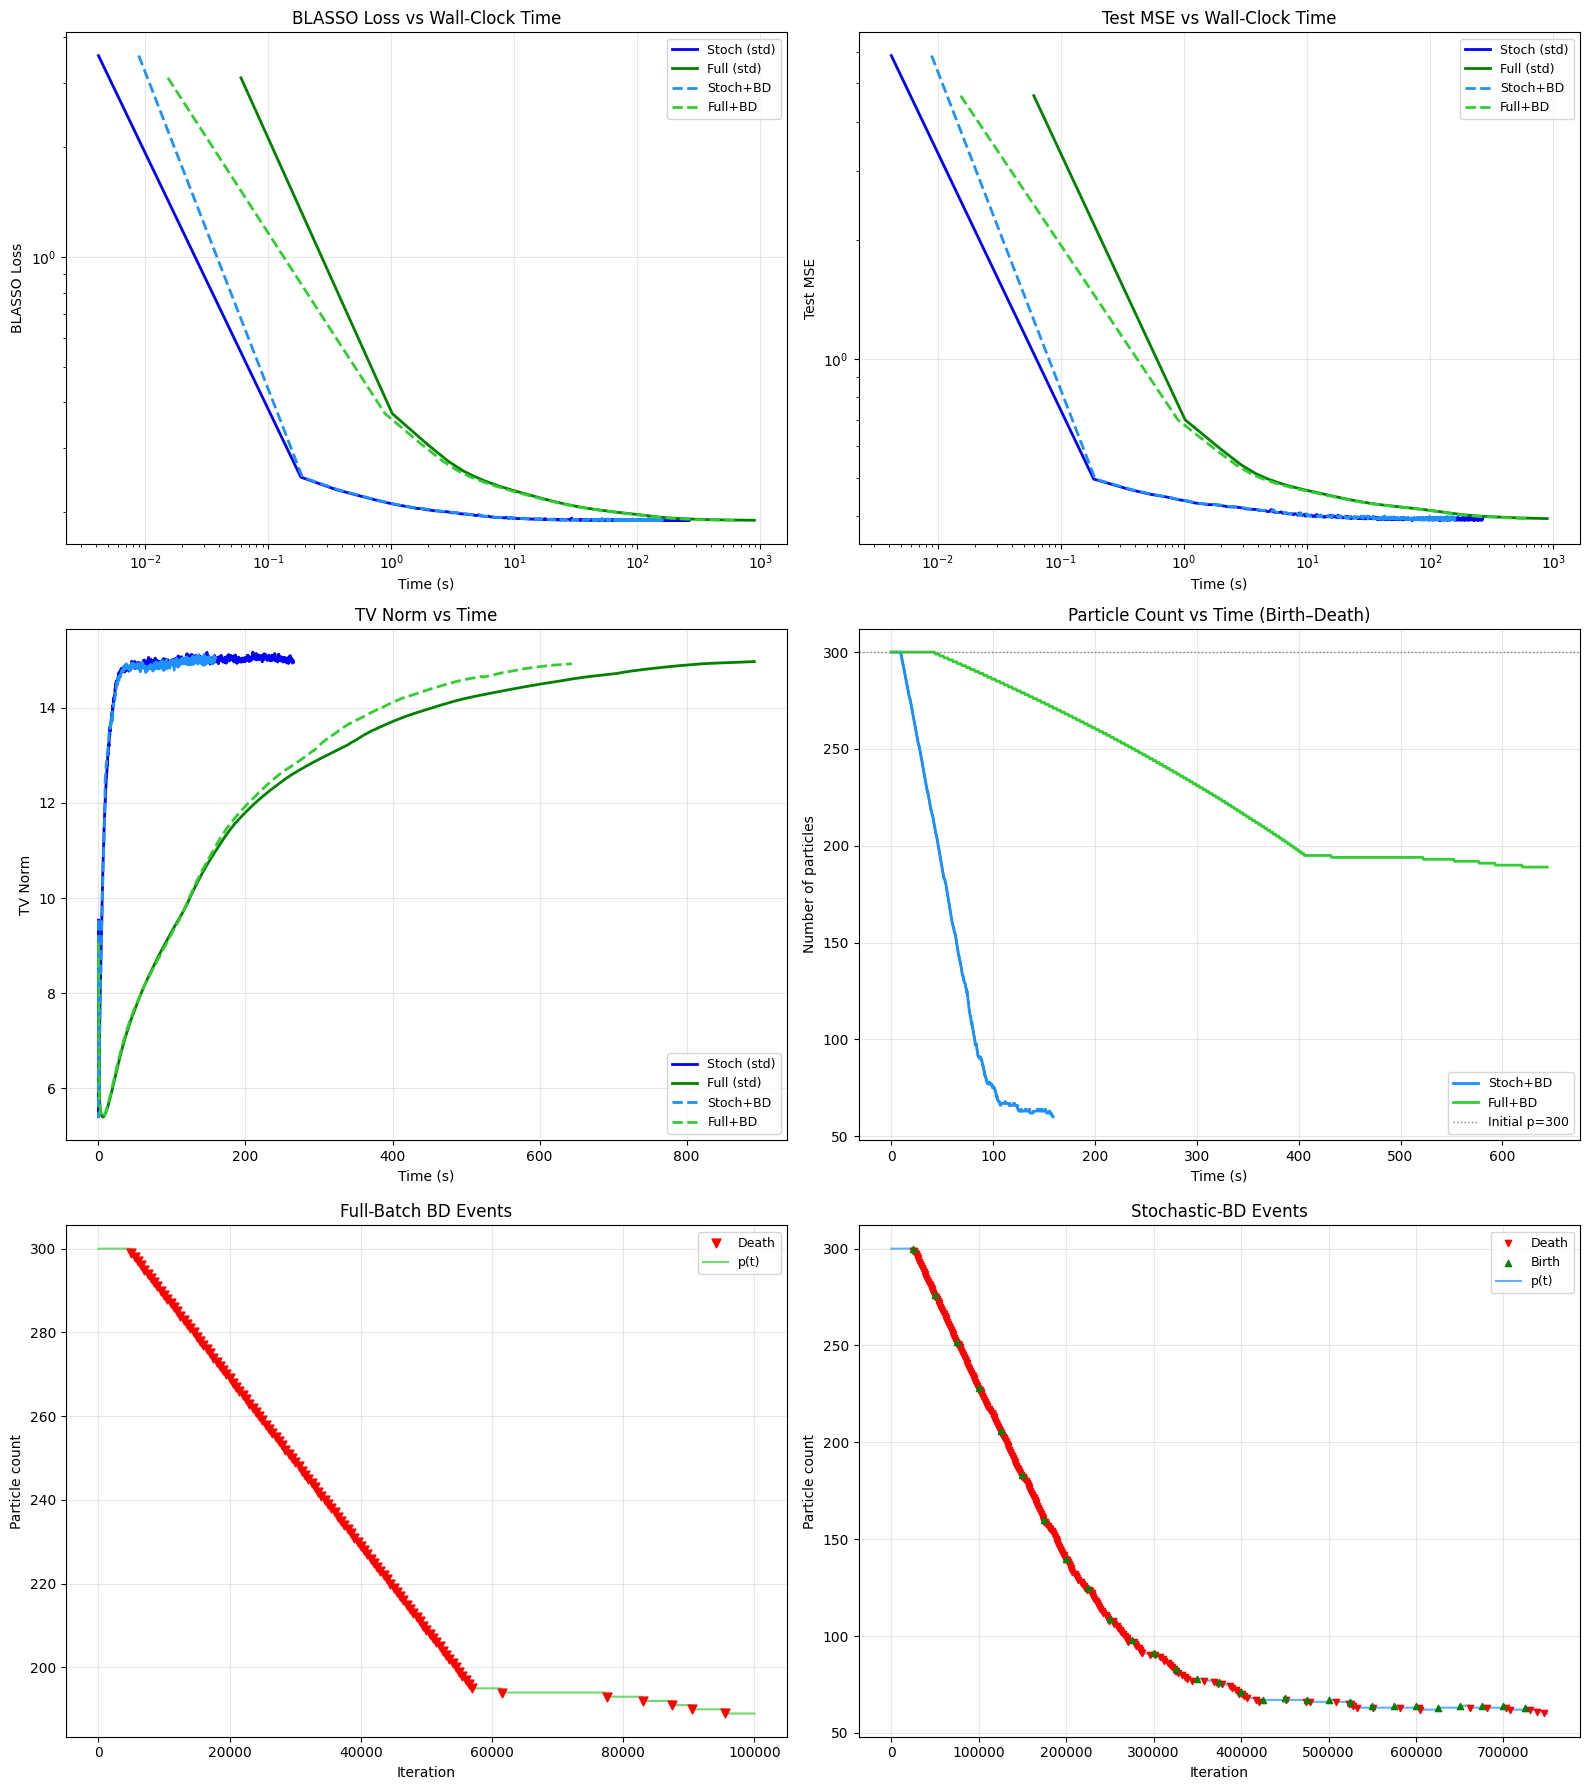


BIRTH–DEATH EXPERIMENT SUMMARY
Method                    MSE(tr)    MSE(te)       TV  p_final    Time(s)  Deaths  Births
------------------------------------------------------------------------------------------
Stochastic (std)         0.366231   0.393154  14.9533      300      265.1       0       0
Full-batch (std)         0.365476   0.393433  14.9645      300      892.2       0       0
Stochastic+BD            0.366369   0.392429  15.0839       60      158.9     269      29
Full-batch+BD            0.365506   0.393495  14.9179      189      644.0     111       0


In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ---- Helper: mark birth/death events on an axis ----
def _mark_events(ax, events_list, times_list, iters_list, color, marker, label):
    """Mark BD events at their wall-clock time on axis `ax`."""
    if not events_list:
        return
    event_steps = [e[0] for e in events_list]
    for k, t_list in enumerate(times_list):
        for step in event_steps:
            # Find closest logged step
            idx_close = min(range(len(iters_list)),
                            key=lambda i: abs(iters_list[i] - step))
            t_event = t_list[idx_close]
            ax.axvline(t_event, color=color, alpha=0.35, linewidth=0.8)
    # One legend entry
    ax.axvline(None, color=color, alpha=0.6, linewidth=1.2,
               linestyle='--', label=label)

# ---- Plot 1: BLASSO loss vs time ----
ax = axes[0, 0]
ax.plot(nn_times,            nn_losses_full,      lw=2, color='blue',       label='Stoch (std)')
ax.plot(nn_times_full_batch, nn_losses_full_batch,lw=2, color='green',      label='Full (std)')
ax.plot(bd_sto_times,        bd_sto_losses_full,  lw=2, color='dodgerblue', label='Stoch+BD',  linestyle='--')
ax.plot(bd_full_times,       bd_full_losses,      lw=2, color='limegreen',  label='Full+BD',   linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('BLASSO Loss')
ax.set_title('BLASSO Loss vs Wall-Clock Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.set_xscale('log')

# ---- Plot 2: Test MSE vs time ----
ax = axes[0, 1]
ax.plot(nn_times,            nn_mse_test,          lw=2, color='blue',       label='Stoch (std)')
ax.plot(nn_times_full_batch, nn_mse_test_full_batch,lw=2,color='green',      label='Full (std)')
ax.plot(bd_sto_times,        bd_sto_mse_test,      lw=2, color='dodgerblue', label='Stoch+BD',  linestyle='--')
ax.plot(bd_full_times,       bd_full_mse_test,     lw=2, color='limegreen',  label='Full+BD',   linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Test MSE')
ax.set_title('Test MSE vs Wall-Clock Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.set_xscale('log')

# ---- Plot 3: TV norm vs time ----
ax = axes[1, 0]
ax.plot(nn_times,            nn_tv_norms,            lw=2, color='blue',       label='Stoch (std)')
ax.plot(nn_times_full_batch, nn_tv_norms_full_batch, lw=2, color='green',      label='Full (std)')
ax.plot(bd_sto_times,        bd_sto_tv_norms,        lw=2, color='dodgerblue', label='Stoch+BD',  linestyle='--')
ax.plot(bd_full_times,       bd_full_tv_norms,       lw=2, color='limegreen',  label='Full+BD',   linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('TV Norm')
ax.set_title('TV Norm vs Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
#ax.set_xscale('log')

# ---- Plot 4: particle count vs time ----
ax = axes[1, 1]
ax.plot(bd_sto_times,  bd_sto_n_particles,  lw=2, color='dodgerblue', label='Stoch+BD')
ax.plot(bd_full_times, bd_full_n_particles, lw=2, color='limegreen',  label='Full+BD')
ax.axhline(NN_N_PARTICLES, color='grey', linestyle=':', lw=1, label=f'Initial p={NN_N_PARTICLES}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Number of particles')
ax.set_title('Particle Count vs Time (Birth–Death)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
#ax.set_xscale('log')

# ---- Plot 5: birth/death event timeline – full-batch ----
ax = axes[2, 0]
if bd_full_deaths:
    death_steps_f, death_p_f = zip(*bd_full_deaths)
    ax.scatter(death_steps_f, death_p_f, color='red',  marker='v', s=40, label='Death', zorder=3)
if bd_full_births:
    birth_steps_f, birth_p_f = zip(*bd_full_births)
    ax.scatter(birth_steps_f, birth_p_f, color='green', marker='^', s=40, label='Birth', zorder=3)
ax.plot(bd_full_iters, bd_full_n_particles, lw=1.5, color='limegreen', alpha=0.7, label='p(t)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Particle count')
ax.set_title('Full-Batch BD Events')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)


# ---- Plot 6: birth/death event timeline – stochastic ----
ax = axes[2, 1]
if bd_sto_deaths:
    death_steps_s, death_p_s = zip(*bd_sto_deaths)
    ax.scatter(death_steps_s, death_p_s, color='red',   marker='v', s=20, label='Death', zorder=3)
if bd_sto_births:
    birth_steps_s, birth_p_s = zip(*bd_sto_births)
    ax.scatter(birth_steps_s, birth_p_s, color='green', marker='^', s=20, label='Birth', zorder=3)
ax.plot(bd_sto_iters, bd_sto_n_particles, lw=1.5, color='dodgerblue', alpha=0.7, label='p(t)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Particle count')
ax.set_title('Stochastic-BD Events')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
#ax.set_xscale('log')

plt.tight_layout()
plt.show()

# ---- Summary table ----
print("\n" + "=" * 90)
print("BIRTH–DEATH EXPERIMENT SUMMARY")
print("=" * 90)
rows = [
    ("Stochastic (std)",   nn_mse_train[-1],             nn_mse_test[-1],
     nn_tv_norms[-1],      NN_N_PARTICLES,               nn_times[-1],   0, 0),
    ("Full-batch (std)",   nn_mse_train_full_batch[-1],  nn_mse_test_full_batch[-1],
     nn_tv_norms_full_batch[-1], NN_N_PARTICLES,         nn_times_full_batch[-1], 0, 0),
    ("Stochastic+BD",      bd_sto_mse_train[-1],         bd_sto_mse_test[-1],
     bd_sto_tv_norms[-1],  bd_sto_n_particles[-1],       bd_sto_times[-1],
     len(bd_sto_deaths),   len(bd_sto_births)),
    ("Full-batch+BD",      bd_full_mse_train[-1],        bd_full_mse_test[-1],
     bd_full_tv_norms[-1], bd_full_n_particles[-1],      bd_full_times[-1],
     len(bd_full_deaths),  len(bd_full_births)),
]
header = f"{'Method':<22} {'MSE(tr)':>10} {'MSE(te)':>10} {'TV':>8} {'p_final':>8} {'Time(s)':>10} {'Deaths':>7} {'Births':>7}"
print(header)
print("-" * 90)
for r in rows:
    print(f"{r[0]:<22} {r[1]:>10.6f} {r[2]:>10.6f} {r[3]:>8.4f} {r[4]:>8d} {r[5]:>10.1f} {r[6]:>7d} {r[7]:>7d}")
print("=" * 90)


## 13. Dual Certificate $\eta$ at Particle Positions

Since $\eta : \mathcal{X} \to \mathbb{R}$ lives in dimension $d+1 = 9$, we cannot plot it as a function.
Instead we visualise its values **at the current particle positions** jointly with the weights $\omega_i$.

### Setting

All particles carry sign $\varepsilon_i = +1$, so the measure is **non-negative**:
$\nu = \sum_i \omega_i \delta_{\vartheta_i}$, $\omega_i > 0$.
On the sphere, a position $-\vartheta$ with sign $+1$ is equivalent to $\vartheta$ with sign $-1$,
so fixing $\varepsilon_i = +1$ and letting positions vary freely on $\mathbb{S}^{d}$ covers the full signed-measure setting.

### Definition

The **dual certificate** is the normalised inner product between the feature map and the current residual:
$$
\eta(t) = \frac{\langle \varphi_t,\, y - \Phi(\nu)\rangle_{\mathbb{H}}}{\kappa}
= \frac{k_y(t) - \mathbb{K}(t,\cdot)^\top\omega}{\kappa}
= 1 - \frac{\texttt{ev.Jp}[i]}{\kappa}
$$
With this normalisation the KKT conditions compare $\eta$ to $+1$.

### KKT conditions (non-negative BLASSO)

**1. Dual feasibility (global bound)**
$$
\forall t\in\mathcal{X},\quad \eta(t) \le 1
\qquad\Longleftrightarrow\qquad J'_\nu(t) \ge 0
$$

**2. Complementary slackness (active particles)**

Every active particle saturates the bound:
$$
\eta(\vartheta_i) = +1 \qquad\Longleftrightarrow\qquad J'_\nu(\vartheta_i) = 0
$$

**3. Birth / Death thresholds in BD process**

| Event | Criterion | Meaning |
|---|---|---|
| Death | $J'_\nu(\vartheta_i)/\omega_i > \tau_\text{death}$ | particle far from active set |
| Birth | $\min_t J'_\nu(t) < -\tau_\text{birth}$ | dual feasibility violated |

### Reading the scatter plot

| Axis | Quantity |
|---|---|
| $x$ | $\omega_i$ (weight) |
| $y$ | $\eta(\vartheta_i) = 1 - J'_\nu(\vartheta_i)/\kappa$ (dual certificate) |

The green dashed line at $y=1$ is the **KKT saturation target**.
A well-converged solution has all active particles (large $\omega_i$) clustering near $y = +1$.
Marker size is proportional to $\omega_i$.


Particle counts at end of dynamic:
  Full-Batch CPGD (no BD)                       p = 300
  Stochastic CPGD (no BD)                       p = 300
  Full-Batch CPGD + Birth–Death                 p = 189
  Stochastic CPGD + Birth–Death                 p = 60


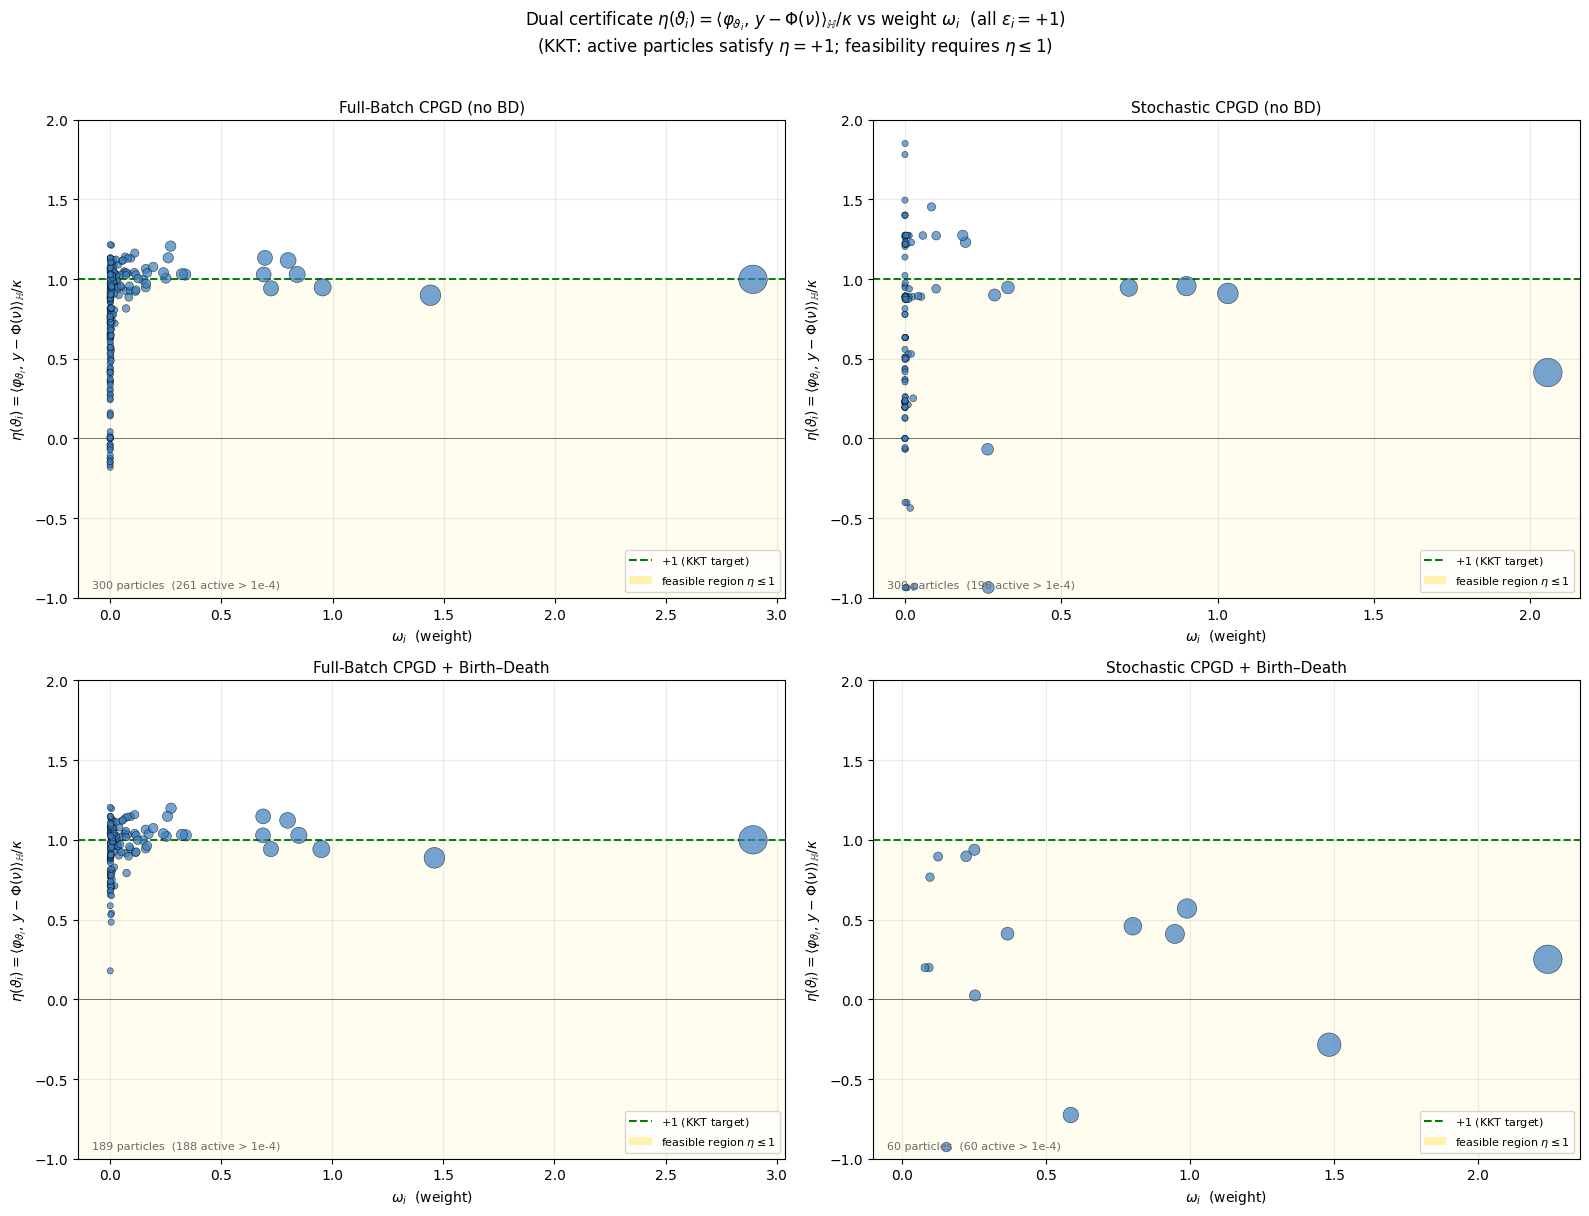


KKT residual summary  |eta(theta_i) - 1| at active particles (omega_i > 1e-4):
Method                                    p_total p_active  mean|res|   max|res|
--------------------------------------------------------------------------------
Full-Batch CPGD (no BD)                       300      261    0.16782    1.06323
Stochastic CPGD (no BD)                       300      196    7.66104   29.34408
Full-Batch CPGD + Birth–Death                 189      188    0.10266    0.82135
Stochastic CPGD + Birth–Death                  60       60   18.25893   49.58820


In [18]:

def plot_eta_scatter(ax, particles: "Particles", problem: "NNBlasso",
                     title: str, kappa: float) -> None:
    """
    Scatter plot of the normalised dual certificate eta(theta_i) vs omega_i.

    All particles have sign = +1 (non-negative measure), so:
        eta(theta) = <phi_theta, y - Phi(nu)>_H / kappa
                   = (kappa - ev.Jp[i]) / kappa
                   = 1 - ev.Jp[i] / kappa

    KKT condition (non-negative BLASSO):
      - feasibility : eta(theta) <= 1  for all theta  (J'_nu >= 0)
      - active      : eta(theta_i) = +1               (J'_nu = 0)

    x-axis : omega_i   (weight, always > 0)
    y-axis : eta(theta_i)  (normalised dual certificate)

    Size   : proportional to omega_i
    """
    with torch.no_grad():
        ev          = problem(particles)
        jp          = ev.Jp.detach().cpu().numpy()              # J'_nu(theta_i), shape (p,)
        eta         = (kappa - jp) / kappa                     # normalised dual certificate
        weights_np  = particles.weights.detach().cpu().numpy()  # (p,) > 0

    sizes   = 20 + 400 * weights_np / (weights_np.max() + 1e-12)

    ax.scatter(weights_np, eta, c='#3a7ebf', s=sizes, alpha=0.7,
               linewidths=0.4, edgecolors='k', zorder=3)

    # KKT saturation target: eta = +1 for all active particles
    ax.axhline(+1., color='green', linestyle='--', linewidth=1.4,
               label=r'$\eta = +1$ (KKT target)')
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.5)

    # Shade the feasible region eta <= 1 (everything below the green line)
    ylim_lo = -1.0  # fixed lower limit for better comparability across plots
    ax.axhspan(ylim_lo, 1.0, alpha=0.06, color='gold', label=r'feasible region $\eta \leq 1$')

    # Adaptive y-limits: show all data + 15% padding, always include +1
    eta_min = min(eta.min(), -0.1)
    eta_max = max(eta.max(), +1.0)
    margin  = max(0.15 * (eta_max - eta_min), 0.15)
    ax.set_ylim(-1, 2)

    # Legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Line2D([0],[0], linestyle='--', color='green',
               label=r'$+1$ (KKT target)'),
        Patch(facecolor='gold', alpha=0.3, label=r'feasible region $\eta \leq 1$'),
    ], fontsize=8, loc='lower right')

    ax.set_xlabel(r'$\omega_i$  (weight)', fontsize=10)
    ax.set_ylabel(
        r'$\eta(\vartheta_i) = \langle\varphi_{\vartheta_i},\,y-\Phi(\nu)\rangle_{\mathbb{H}}/\kappa$',
        fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25)

    n_active = int((weights_np > 1e-4).sum())
    ax.annotate(f'{len(particles)} particles  ({n_active} active > 1e-4)',
                xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8,
                color='dimgrey')


# ---- Four-panel figure -------------------------------------------------------
# Particles at the END of each dynamic:
#   no-BD  → nn_optimizer_full.particles  (100 particles, updated in-place)
#           / nn_optimizer.particles
#   + BD   → nn_opt_full_bd.particles     (≤ 100 particles, reassigned at each BD event)
#           / nn_opt_sto_bd.particles
configs = [
    (nn_optimizer_full.particles, nn_problem, 'Full-Batch CPGD (no BD)'),
    (nn_optimizer.particles,      nn_problem, 'Stochastic CPGD (no BD)'),
    (nn_opt_full_bd.particles,    nn_problem, 'Full-Batch CPGD + Birth–Death'),
    (nn_opt_sto_bd.particles,     nn_problem, 'Stochastic CPGD + Birth–Death'),
]

# Sanity-check: print particle counts to confirm end-of-dynamic state
print("Particle counts at end of dynamic:")
for parts, _, title in configs:
    print(f"  {title:<45} p = {len(parts)}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (parts, prob, title) in zip(axes.flat, configs):
    plot_eta_scatter(ax, parts, prob, title, kappa=NN_KAPPA)

plt.suptitle(
    r"Dual certificate $\eta(\vartheta_i) = \langle\varphi_{\vartheta_i},\,y-\Phi(\nu)\rangle_{\mathbb{H}}/\kappa$"
    r" vs weight $\omega_i$  (all $\varepsilon_i = +1$)"
    "\n"
    r"(KKT: active particles satisfy $\eta = +1$; "
    r"feasibility requires $\eta \leq 1$)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

# ---- Per-algorithm KKT residual summary ----------------------------------------
print("\nKKT residual summary  |eta(theta_i) - 1| at active particles (omega_i > 1e-4):")
print(f"{'Method':<40} {'p_total':>8} {'p_active':>8} {'mean|res|':>10} {'max|res|':>10}")
print("-" * 80)
for parts, prob, title in configs:
    with torch.no_grad():
        ev          = prob(parts)
        jp          = ev.Jp.detach().cpu().numpy()
        eta         = (NN_KAPPA - jp) / NN_KAPPA
        w           = parts.weights.detach().cpu().numpy()
        active      = w > 1e-4
        # KKT target: +1 for all particles (eps = +1 always)
        residuals   = np.abs(eta - 1.0)
        res_act     = residuals[active] if active.any() else np.array([0.])
    print(f"{title:<40} {len(parts):>8d} {int(active.sum()):>8d} "
          f"{res_act.mean():>10.5f} {res_act.max():>10.5f}")


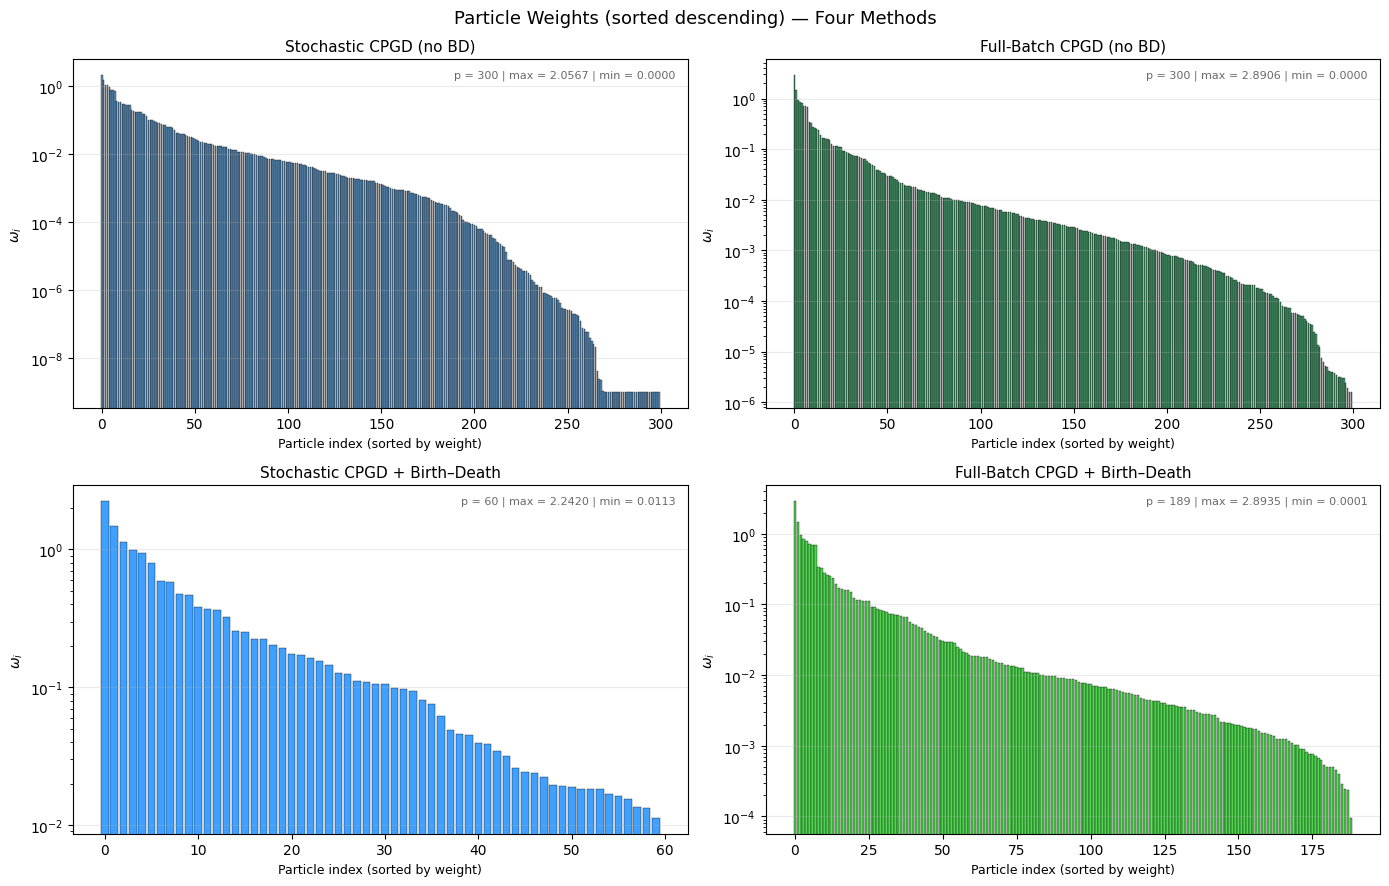

In [19]:

# ============================================================
# Particle weights — four methods
# ============================================================

_configs = [
    (nn_particles,                'Stochastic CPGD (no BD)',        'steelblue'),
    (nn_particles_full,           'Full-Batch CPGD (no BD)',         'seagreen'),
    (nn_opt_sto_bd.particles,     'Stochastic CPGD + Birth–Death',  'dodgerblue'),
    (nn_opt_full_bd.particles,    'Full-Batch CPGD + Birth–Death',  'limegreen'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (parts, title, color) in zip(axes.flat, _configs):
    w = parts.weights.detach().cpu().numpy()
    idx_sorted = np.argsort(w)[::-1]
    w_sorted   = w[idx_sorted]

    ax.bar(np.arange(len(w_sorted)), w_sorted,
           color=color, alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.set_xlabel('Particle index (sorted by weight)', fontsize=9)
    ax.set_ylabel(r'$\omega_i$', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25, axis='y')
    ax.set_yscale('log')
    ax.annotate(
        f'p = {len(w)} | max = {w_sorted[0]:.4f} | min = {w_sorted[-1]:.4f}',
        xy=(0.98, 0.97), xycoords='axes fraction',
        fontsize=8, color='dimgrey', ha='right', va='top'
    )

plt.suptitle('Particle Weights (sorted descending) — Four Methods', fontsize=13)
plt.tight_layout()
plt.show()


Random projection axes: coordinate 7 (x) and coordinate 6 (y)    [theta_dim = 9]


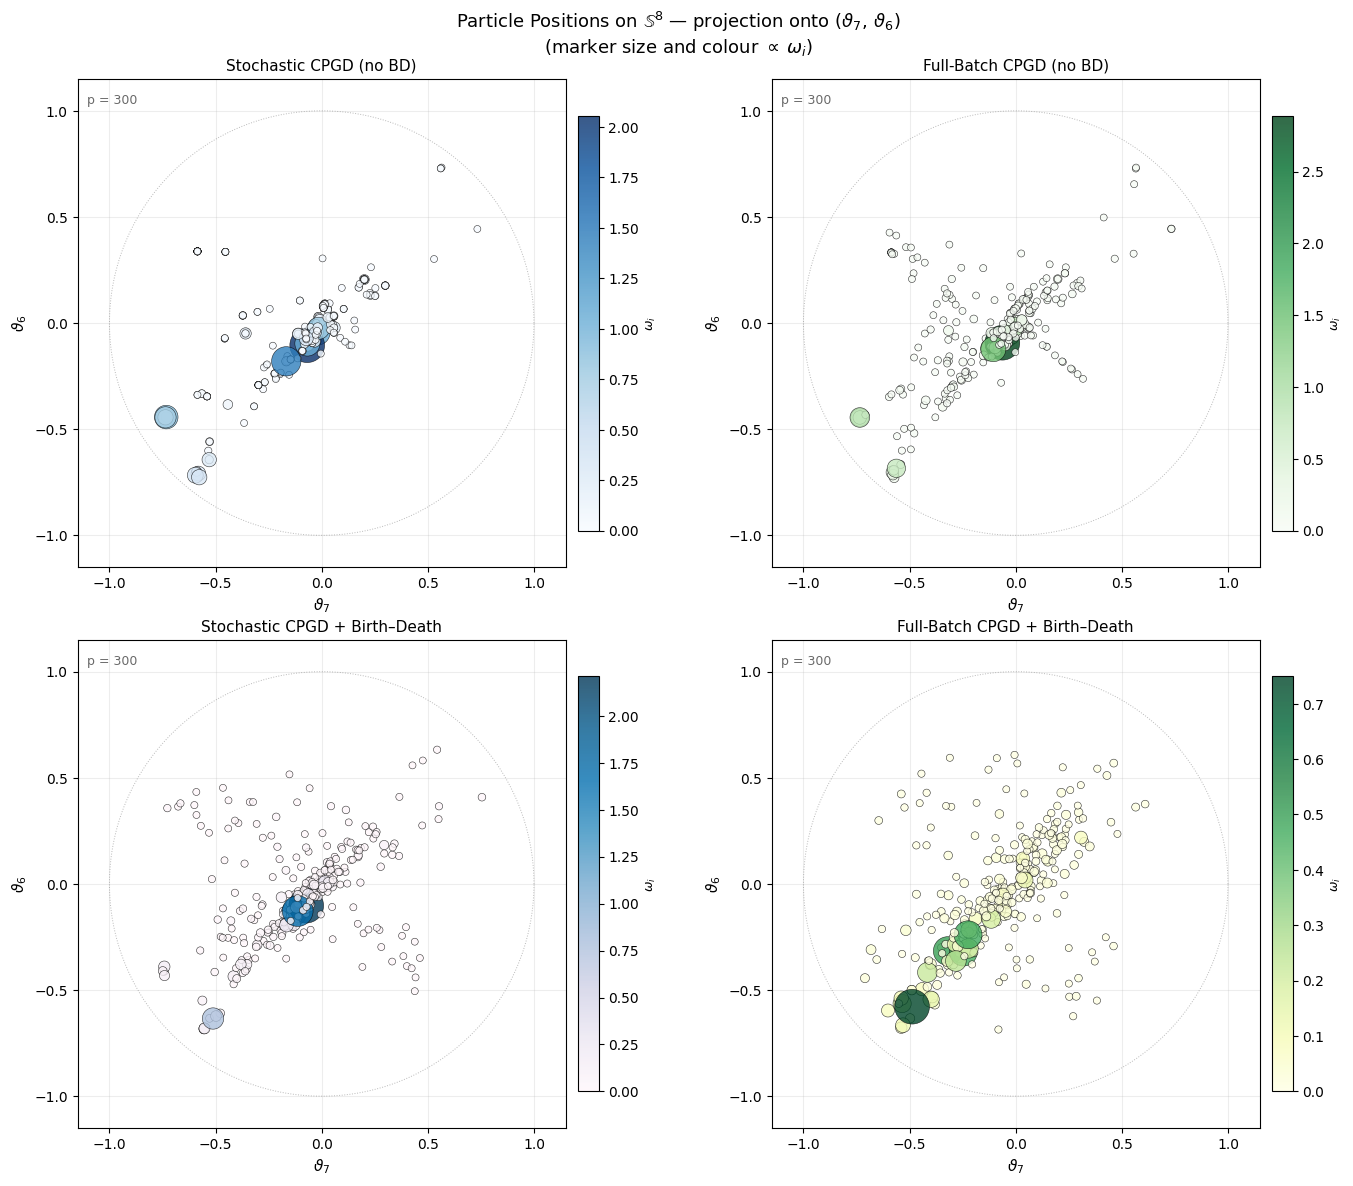

In [20]:

# ============================================================
# Particle positions on the unit sphere — 2-D projection
# Two coordinate axes chosen at random (same for all methods)
# Marker size and colour ∝ weight
# ============================================================

rng_proj = np.random.default_rng()        #(seed=2026)
dim1, dim2 = rng_proj.choice(NN_THETA_DIM, size=2, replace=False)
print(f"Random projection axes: coordinate {dim1} (x) and coordinate {dim2} (y)  "
      f"  [theta_dim = {NN_THETA_DIM}]")

_configs = [
    (nn_particles,         'Stochastic CPGD (no BD)',        'Blues'),
    (nn_particles_full,    'Full-Batch CPGD (no BD)',         'Greens'),
    (nn_particles_sto_bd,  'Stochastic CPGD + Birth–Death',  'PuBu'),
    (nn_particles_full_bd, 'Full-Batch CPGD + Birth–Death',  'YlGn'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Unit-circle arc for reference (projection of S^{d-1} onto the two axes)
_theta_circ = np.linspace(0, 2 * np.pi, 400)
_cx, _cy    = np.cos(_theta_circ), np.sin(_theta_circ)

for ax, (parts, title, cmap) in zip(axes.flat, _configs):
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()   # (p, theta_dim)
        w   = parts.weights.detach().cpu().numpy()     # (p,)

    x = pos[:, dim1]
    y = pos[:, dim2]

    # Marker area proportional to weight
    sizes = 25 + 600 * w / (w.max() + 1e-12)

    sc = ax.scatter(x, y, s=sizes, c=w, cmap=cmap,
                    vmin=0., vmax=w.max(),
                    alpha=0.80, edgecolors='k', linewidths=0.4, zorder=3)
    cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label(r'$\omega_i$', fontsize=9)

    # Reference circle (unit sphere projected)
    ax.plot(_cx, _cy, color='grey', lw=0.7, linestyle=':', alpha=0.55,
            label='unit circle')

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')
    ax.set_xlabel(rf'$\vartheta_{{{dim1}}}$', fontsize=11)
    ax.set_ylabel(rf'$\vartheta_{{{dim2}}}$', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.22)
    ax.annotate(f'p = {len(w)}',
                xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=9, color='dimgrey', va='top')

plt.suptitle(
    rf'Particle Positions on $\mathbb{{S}}^{{{NN_THETA_DIM - 1}}}$ — '
    rf'projection onto $(\vartheta_{{{dim1}}},\, \vartheta_{{{dim2}}})$'
    '\n' r'(marker size and colour $\propto\,\omega_i$)',
    fontsize=13
)
plt.tight_layout()
plt.show()


Weight-averaged squared norm per coordinate (pooled):
  coord  0: 1.1828
  coord  1: 0.5155
  coord  2: 2.8124
  coord  3: 1.9063
  coord  4: 0.5976
  coord  5: 26.2946 ◄
  coord  6: 4.2823
  coord  7: 5.0779 ◄
  coord  8: 6.1838 [bias]

Selected axes: coordinate 5 (x) and coordinate 7 (y)


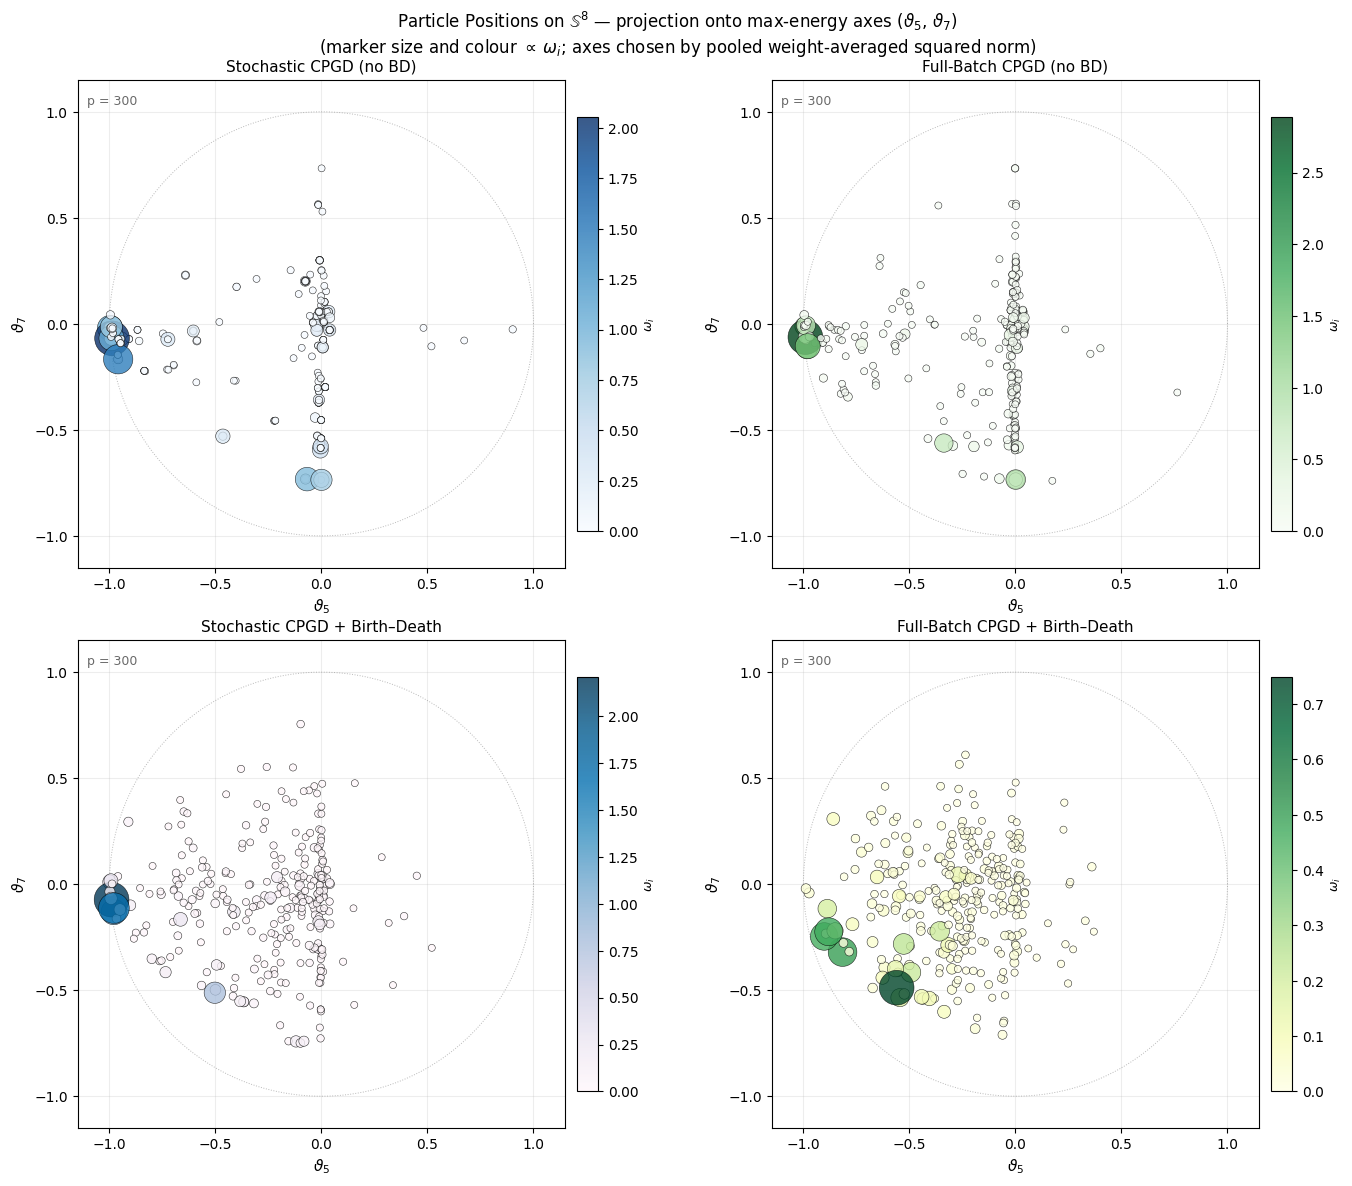

In [21]:

# ============================================================
# Particle positions on the sphere — projection onto the two
# coordinates with maximal weight-averaged squared norm
# (pooled over all four particle sets)
# ============================================================

_all_configs = [
    (nn_particles,         'Stochastic CPGD (no BD)',        'Blues'),
    (nn_particles_full,    'Full-Batch CPGD (no BD)',         'Greens'),
    (nn_particles_sto_bd,  'Stochastic CPGD + Birth–Death',  'PuBu'),
    (nn_particles_full_bd, 'Full-Batch CPGD + Birth–Death',  'YlGn'),
]

# ---- Find the two most energetic coordinates (pooled) ----------------------
# For each coordinate k, compute  sum_i  w_i * theta_{i,k}^2  (per method),
# then average over methods so the choice is representative of all four.
# The last coordinate is the bias and is excluded from selection.
coord_energy = np.zeros(NN_THETA_DIM)
for parts, _, _ in _all_configs:
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()  # (p, d+1)
        w   = parts.weights.detach().cpu().numpy()    # (p,)
    coord_energy += (w[:, None] * pos ** 2).sum(axis=0)

# Exclude the last (bias) coordinate from axis selection
top2    = np.argsort(coord_energy[:-1])[::-1][:2]
ax1, ax2 = int(top2[0]), int(top2[1])

print("Weight-averaged squared norm per coordinate (pooled):")
for k, e in enumerate(coord_energy):
    marker = " ◄" if k in (ax1, ax2) else (" [bias]" if k == NN_THETA_DIM - 1 else "")
    print(f"  coord {k:2d}: {e:.4f}{marker}")
print(f"\nSelected axes: coordinate {ax1} (x) and coordinate {ax2} (y)")

# ---- Plot ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

_theta_circ = np.linspace(0, 2 * np.pi, 400)
_cx, _cy    = np.cos(_theta_circ), np.sin(_theta_circ)

for ax, (parts, title, cmap) in zip(axes.flat, _all_configs):
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()
        w   = parts.weights.detach().cpu().numpy()

    x     = pos[:, ax1]
    y_pos = pos[:, ax2]
    sizes = 25 + 600 * w / (w.max() + 1e-12)

    sc = ax.scatter(x, y_pos, s=sizes, c=w, cmap=cmap,
                    vmin=0., vmax=w.max(),
                    alpha=0.80, edgecolors='k', linewidths=0.4, zorder=3)
    cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label(r'$\omega_i$', fontsize=9)

    ax.plot(_cx, _cy, color='grey', lw=0.7, linestyle=':', alpha=0.55)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')
    ax.set_xlabel(rf'$\vartheta_{{{ax1}}}$', fontsize=11)
    ax.set_ylabel(rf'$\vartheta_{{{ax2}}}$', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.22)
    ax.annotate(f'p = {len(w)}',
                xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=9, color='dimgrey', va='top')

plt.suptitle(
    rf'Particle Positions on $\mathbb{{S}}^{{{NN_THETA_DIM - 1}}}$ — '
    rf'projection onto max-energy axes $(\vartheta_{{{ax1}}},\, \vartheta_{{{ax2}}})$'
    '\n' r'(marker size and colour $\propto\,\omega_i$; '
    r'axes chosen by pooled weight-averaged squared norm)',
    fontsize=12
)
plt.tight_layout()
plt.show()


PCA fitted on 1200 pooled positions (theta_dim = 9)
  PC1 explains 39.5%  of variance
  PC2 explains 22.2%  of variance (cumulative: 61.7%)


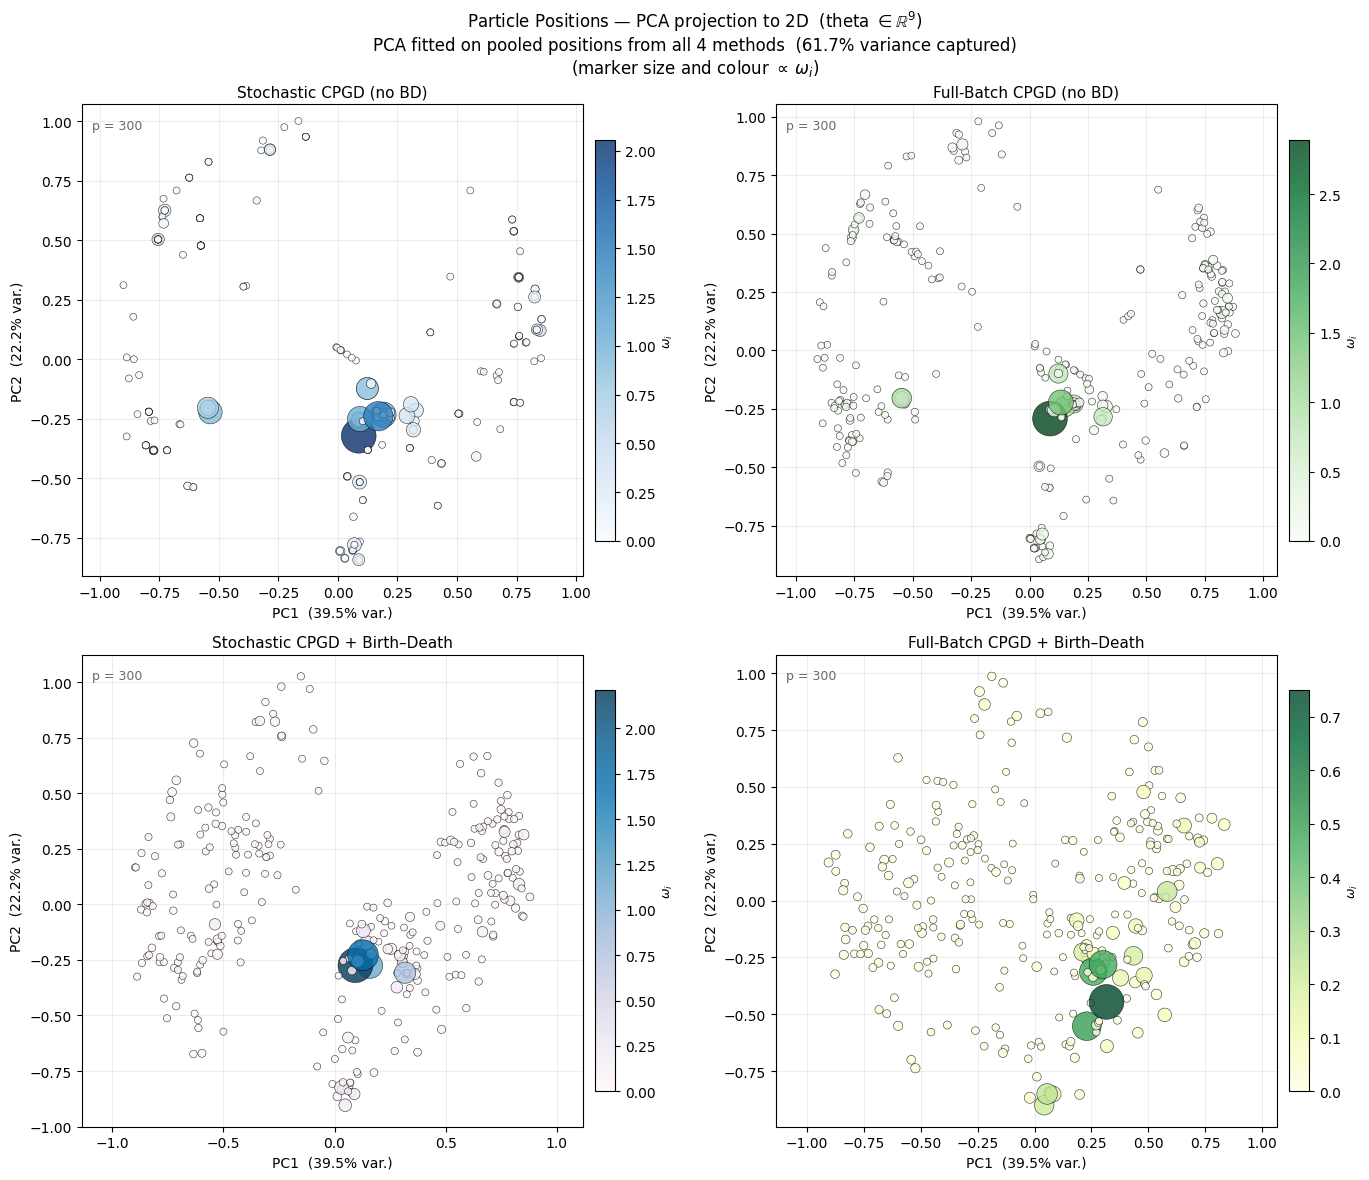

In [22]:

# ============================================================
# Particle positions on the sphere — PCA projection to 2D
# PCA is fitted once on the POOLED positions of all 4 methods
# so all panels share the same pair of axes.
# ============================================================

from sklearn.decomposition import PCA

_all_configs_pca = [
    (nn_particles,         'Stochastic CPGD (no BD)',        'Blues'),
    (nn_particles_full,    'Full-Batch CPGD (no BD)',         'Greens'),
    (nn_particles_sto_bd,  'Stochastic CPGD + Birth–Death',  'PuBu'),
    (nn_particles_full_bd, 'Full-Batch CPGD + Birth–Death',  'YlGn'),
]

# ---- Fit PCA on pooled positions (all 4 methods) ---------------------------
_all_pos = []
for parts, _, _ in _all_configs_pca:
    with torch.no_grad():
        _all_pos.append(parts.positions.detach().cpu().numpy())

_pooled_pos = np.vstack(_all_pos)   # (sum_p, theta_dim)
pca = PCA(n_components=2, random_state=314)
pca.fit(_pooled_pos)

var_ratio = pca.explained_variance_ratio_
print(f"PCA fitted on {_pooled_pos.shape[0]} pooled positions "
      f"(theta_dim = {NN_THETA_DIM})")
print(f"  PC1 explains {100*var_ratio[0]:.1f}%  of variance")
print(f"  PC2 explains {100*var_ratio[1]:.1f}%  of variance "
      f"(cumulative: {100*var_ratio.sum():.1f}%)")

# ---- Plot ------------------------------------------------------------------
fig_pca, axes_pca = plt.subplots(2, 2, figsize=(14, 12))

for ax, (parts, title, cmap) in zip(axes_pca.flat, _all_configs_pca):
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()   # (p, theta_dim)
        w   = parts.weights.detach().cpu().numpy()     # (p,)

    # Project onto the 2 principal components
    proj = pca.transform(pos)                          # (p, 2)
    pc1, pc2 = proj[:, 0], proj[:, 1]

    sizes = 25 + 600 * w / (w.max() + 1e-12)

    sc = ax.scatter(pc1, pc2, s=sizes, c=w, cmap=cmap,
                    vmin=0., vmax=w.max(),
                    alpha=0.80, edgecolors='k', linewidths=0.4, zorder=3)
    cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label(r'$\omega_i$', fontsize=9)

    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel(rf'PC1  ({100*var_ratio[0]:.1f}% var.)', fontsize=10)
    ax.set_ylabel(rf'PC2  ({100*var_ratio[1]:.1f}% var.)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.22)
    ax.annotate(f'p = {len(w)}',
                xy=(0.02, 0.97), xycoords='axes fraction',
                fontsize=9, color='dimgrey', va='top')

plt.suptitle(
    rf'Particle Positions — PCA projection to 2D'
    rf'  (theta $\in \mathbb{{R}}^{{{NN_THETA_DIM}}}$)'
    '\n'
    rf'PCA fitted on pooled positions from all 4 methods  '
    rf'({100*var_ratio.sum():.1f}% variance captured)'
    '\n'
    r'(marker size and colour $\propto\,\omega_i$)',
    fontsize=12
)
plt.tight_layout()
display(fig_pca)
plt.close(fig_pca)


## 14. Export Results

Save all figures as PDF (for LaTeX), the notebook as HTML and PDF, and all parameters in a plain-text file.


In [23]:
import os
import subprocess
import datetime
import matplotlib
matplotlib.use("Agg")   # non-interactive backend for PDF saving

# ── 1. Output directory (date-stamped) ──────────────────────────────────────
timestamp   = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
NB_PATH     = os.path.abspath("experiments_fastpart_nn_california.ipynb")
RESULTS_DIR = os.path.join(os.path.dirname(NB_PATH),
                            f"results_nn_california_{timestamp}")
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}\n")

# ── 2. Helpers ───────────────────────────────────────────────────────────────
def save_pdf(fig, name: str) -> None:
    path = os.path.join(RESULTS_DIR, name)
    fig.savefig(path, format="pdf", bbox_inches="tight", dpi=300)
    print(f"  [PDF] {name}")

# Line-style convention: no BD = dashed, BD = solid
LS_NO_BD = "--"
LS_BD    = "-"

nn_epochs_sto_   = [it * NN_BATCH_SIZE / len(X_train_tensor) for it in nn_iterations]
nn_epochs_full_  = list(nn_iterations_full_batch)

# ── 3. Fig 1a – BLASSO Loss vs time (no-BD) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_times,            nn_losses_full,       lw=2, ls=LS_NO_BD, color="blue",  label="Stochastic")
ax.plot(nn_times_full_batch, nn_losses_full_batch, lw=2, ls=LS_NO_BD, color="green", label="Full-batch")
ax.set_xlabel("Time (s)"); ax.set_ylabel("BLASSO Loss")
ax.set_title("BLASSO Loss vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig1a_loss_vs_time.pdf"); plt.close(fig)

# ── 4. Fig 1b – MSE (train & test) vs time (no-BD) ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_times,            nn_mse_train,             lw=2, ls=LS_NO_BD, color="blue",           label="Sto (train)")
ax.plot(nn_times,            nn_mse_test,              lw=2, ls=LS_NO_BD, color="blue",  alpha=0.5, label="Sto (test)")
ax.plot(nn_times_full_batch, nn_mse_train_full_batch,  lw=2, ls=LS_NO_BD, color="green",           label="Full (train)")
ax.plot(nn_times_full_batch, nn_mse_test_full_batch,   lw=2, ls=LS_NO_BD, color="green", alpha=0.5, label="Full (test)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("MSE")
ax.set_title("MSE vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig1b_mse_vs_time.pdf"); plt.close(fig)

# ── 5. Fig 1c – BLASSO Loss vs epochs (no-BD) ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_epochs_sto_,  nn_losses_full,       lw=2, ls=LS_NO_BD, color="blue",  label="Stochastic")
ax.plot(nn_epochs_full_, nn_losses_full_batch, lw=2, ls=LS_NO_BD, color="green", label="Full-batch")
ax.set_xlabel("Epochs"); ax.set_ylabel("BLASSO Loss")
ax.set_title("BLASSO Loss vs Epochs")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log")
fig.tight_layout(); save_pdf(fig, "fig1c_loss_vs_epochs.pdf"); plt.close(fig)

# ── 6. Fig 1d – TV Norm vs time (no-BD) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_times,            nn_tv_norms,            lw=2, ls=LS_NO_BD, color="blue",  label="Stochastic")
ax.plot(nn_times_full_batch, nn_tv_norms_full_batch, lw=2, ls=LS_NO_BD, color="green", label="Full-batch")
ax.set_xlabel("Time (s)"); ax.set_ylabel("TV Norm")
ax.set_title("TV Norm vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig1d_tv_vs_time.pdf"); plt.close(fig)

# ── 7. Fig 2a – BLASSO Loss vs time (4-way) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_times,            nn_losses_full,       lw=2, ls=LS_NO_BD, color="blue",       label="Sto (no BD)")
ax.plot(nn_times_full_batch, nn_losses_full_batch, lw=2, ls=LS_NO_BD, color="green",      label="Full (no BD)")
ax.plot(bd_sto_times,        bd_sto_losses_full,   lw=2, ls=LS_BD,    color="dodgerblue", label="Sto + BD")
ax.plot(bd_full_times,       bd_full_losses,       lw=2, ls=LS_BD,    color="limegreen",  label="Full + BD")
ax.set_xlabel("Time (s)"); ax.set_ylabel("BLASSO Loss")
ax.set_title("BLASSO Loss vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2a_loss_vs_time_bd.pdf"); plt.close(fig)

# ── 8. Fig 2b – Test MSE vs time (4-way) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_times,            nn_mse_test,            lw=2, ls=LS_NO_BD, color="blue",       label="Sto (no BD)")
ax.plot(nn_times_full_batch, nn_mse_test_full_batch, lw=2, ls=LS_NO_BD, color="green",      label="Full (no BD)")
ax.plot(bd_sto_times,        bd_sto_mse_test,        lw=2, ls=LS_BD,    color="dodgerblue", label="Sto + BD")
ax.plot(bd_full_times,       bd_full_mse_test,       lw=2, ls=LS_BD,    color="limegreen",  label="Full + BD")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2b_mse_test_vs_time_bd.pdf"); plt.close(fig)

# ── 9. Fig 2c – TV Norm vs time (4-way) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(nn_times,            nn_tv_norms,            lw=2, ls=LS_NO_BD, color="blue",       label="Sto (no BD)")
ax.plot(nn_times_full_batch, nn_tv_norms_full_batch, lw=2, ls=LS_NO_BD, color="green",      label="Full (no BD)")
ax.plot(bd_sto_times,        bd_sto_tv_norms,        lw=2, ls=LS_BD,    color="dodgerblue", label="Sto + BD")
ax.plot(bd_full_times,       bd_full_tv_norms,       lw=2, ls=LS_BD,    color="limegreen",  label="Full + BD")
ax.set_xlabel("Time (s)"); ax.set_ylabel("TV Norm")
ax.set_title("TV Norm vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2c_tv_vs_time_bd.pdf"); plt.close(fig)

# ── 10. Fig 2d – Particle count vs time (BD only) ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bd_sto_times,  bd_sto_n_particles,  lw=2, ls=LS_BD, color="dodgerblue", label="Sto + BD")
ax.plot(bd_full_times, bd_full_n_particles, lw=2, ls=LS_BD, color="limegreen",  label="Full + BD")
ax.axhline(NN_N_PARTICLES, color="grey", ls=":", lw=1, label=f"Initial $p={NN_N_PARTICLES}$")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Number of particles")
ax.set_title("Particle Count vs Time (Birth–Death)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2d_particle_count_bd.pdf"); plt.close(fig)

# ── 11. Fig 2e – BD events, full-batch ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
if bd_full_deaths:
    d_steps, d_ps = zip(*bd_full_deaths)
    ax.scatter(d_steps, d_ps, color="red",   marker="v", s=40, label="Death", zorder=3)
if bd_full_births:
    b_steps, b_ps = zip(*bd_full_births)
    ax.scatter(b_steps, b_ps, color="green", marker="^", s=40, label="Birth", zorder=3)
ax.plot(bd_full_iters, bd_full_n_particles, lw=1.5, ls=LS_BD, color="limegreen", alpha=0.7, label="p(t)")
ax.set_xlabel("Iteration"); ax.set_ylabel("Particle count")
ax.set_title("Full-Batch BD Events")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); save_pdf(fig, "fig2e_bd_events_full.pdf"); plt.close(fig)

# ── 12. Fig 2f – BD events, stochastic ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
if bd_sto_deaths:
    d_steps, d_ps = zip(*bd_sto_deaths)
    ax.scatter(d_steps, d_ps, color="red",   marker="v", s=20, label="Death", zorder=3)
if bd_sto_births:
    b_steps, b_ps = zip(*bd_sto_births)
    ax.scatter(b_steps, b_ps, color="green", marker="^", s=20, label="Birth", zorder=3)
ax.plot(bd_sto_iters, bd_sto_n_particles, lw=1.5, ls=LS_BD, color="dodgerblue", alpha=0.7, label="p(t)")
ax.set_xlabel("Iteration"); ax.set_ylabel("Particle count")
ax.set_title("Stochastic BD Events")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); save_pdf(fig, "fig2f_bd_events_sto.pdf"); plt.close(fig)

# ── 13. Figs 3a–3d – Dual certificate (one per method) ─────────────────────
_configs_eta = [
    (nn_optimizer.particles,      nn_problem, "Stochastic CPGD (no BD)",       "fig3a_dual_cert_sto.pdf"),
    (nn_optimizer_full.particles, nn_problem, "Full-Batch CPGD (no BD)",        "fig3b_dual_cert_full.pdf"),
    (nn_opt_sto_bd.particles,     nn_problem, "Stochastic CPGD + Birth-Death", "fig3c_dual_cert_sto_bd.pdf"),
    (nn_opt_full_bd.particles,    nn_problem, "Full-Batch CPGD + Birth-Death",  "fig3d_dual_cert_full_bd.pdf"),
]
for parts, prob, title, fname in _configs_eta:
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_eta_scatter(ax, parts, prob, title, kappa=NN_KAPPA)
    fig.tight_layout(); save_pdf(fig, fname); plt.close(fig)

# ── 14. Figs 4a–4d – Particle weights (one per method) ─────────────────────
_configs_w = [
    (nn_particles,             "Stochastic CPGD (no BD)",       "steelblue",  "fig4a_weights_sto.pdf"),
    (nn_particles_full,        "Full-Batch CPGD (no BD)",        "seagreen",   "fig4b_weights_full.pdf"),
    (nn_opt_sto_bd.particles,  "Stochastic CPGD + Birth-Death", "dodgerblue", "fig4c_weights_sto_bd.pdf"),
    (nn_opt_full_bd.particles, "Full-Batch CPGD + Birth-Death",  "limegreen",  "fig4d_weights_full_bd.pdf"),
]
for parts, title, color, fname in _configs_w:
    fig, ax = plt.subplots(figsize=(7, 5))
    w   = parts.weights.detach().cpu().numpy()
    w_s = w[np.argsort(w)[::-1]]
    ax.bar(np.arange(len(w_s)), w_s, color=color, alpha=0.85, edgecolor="k", linewidth=0.3)
    ax.set_xlabel("Particle index (sorted)"); ax.set_ylabel(r"$\omega_i$")
    ax.set_title(title + f"  (p={len(w)})", fontsize=11)
    ax.grid(True, alpha=0.25, axis="y"); ax.set_yscale("log")
    ax.annotate(f"max={w_s[0]:.4f} | min={w_s[-1]:.4f}",
                xy=(0.98, 0.97), xycoords="axes fraction", fontsize=8,
                color="dimgrey", ha="right", va="top")
    fig.tight_layout(); save_pdf(fig, fname); plt.close(fig)

# ── 15. Figs 5a–5d – Positions random projection (one per method) ───────────
rng_proj = np.random.default_rng()
d1_r, d2_r = rng_proj.choice(NN_THETA_DIM, size=2, replace=False)
_configs_pos = [
    (nn_particles,             "Stochastic CPGD (no BD)",       "Blues",   "fig5a_pos_rnd_sto.pdf"),
    (nn_particles_full,        "Full-Batch CPGD (no BD)",        "Greens",  "fig5b_pos_rnd_full.pdf"),
    (nn_particles_sto_bd,      "Stochastic CPGD + Birth-Death", "PuBu",    "fig5c_pos_rnd_sto_bd.pdf"),
    (nn_particles_full_bd,     "Full-Batch CPGD + Birth-Death",  "YlGn",    "fig5d_pos_rnd_full_bd.pdf"),
]
_tc = np.linspace(0, 2 * np.pi, 400)
for parts, title, cmap, fname in _configs_pos:
    fig, ax = plt.subplots(figsize=(6, 6))
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()
        w   = parts.weights.detach().cpu().numpy()
    sc = ax.scatter(pos[:, d1_r], pos[:, d2_r],
                    s=25 + 600 * w / (w.max() + 1e-12), c=w, cmap=cmap,
                    vmin=0, vmax=w.max(), alpha=0.80, edgecolors="k", linewidths=0.4, zorder=3)
    plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85).set_label(r"$\omega_i$", fontsize=9)
    ax.plot(np.cos(_tc), np.sin(_tc), color="grey", lw=0.7, ls=":", alpha=0.55)
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect("equal")
    ax.set_xlabel(rf"$\vartheta_{{{d1_r}}}$", fontsize=11)
    ax.set_ylabel(rf"$\vartheta_{{{d2_r}}}$", fontsize=11)
    ax.set_title(f"{title}  (p={len(w)})", fontsize=11); ax.grid(True, alpha=0.22)
    fig.suptitle(r"(size and colour $\propto\,\omega_i$)", fontsize=9, y=0.01)
    fig.tight_layout(); save_pdf(fig, fname); plt.close(fig)

# ── 16. Figs 6a–6d – Positions max-energy projection (one per method) ───────
coord_e2 = np.zeros(NN_THETA_DIM)
for parts, _, _, _ in _configs_pos:
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()
        w   = parts.weights.detach().cpu().numpy()
    coord_e2 += (w[:, None] * pos ** 2).sum(axis=0)
top2_ = np.argsort(coord_e2[:-1])[::-1][:2]
ax1_, ax2_ = int(top2_[0]), int(top2_[1])

for parts, title, cmap, fname in _configs_pos:
    fig, ax = plt.subplots(figsize=(6, 6))
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()
        w   = parts.weights.detach().cpu().numpy()
    sc = ax.scatter(pos[:, ax1_], pos[:, ax2_],
                    s=25 + 600 * w / (w.max() + 1e-12), c=w, cmap=cmap,
                    vmin=0, vmax=w.max(), alpha=0.80, edgecolors="k", linewidths=0.4, zorder=3)
    plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85).set_label(r"$\omega_i$", fontsize=9)
    ax.plot(np.cos(_tc), np.sin(_tc), color="grey", lw=0.7, ls=":", alpha=0.55)
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect("equal")
    ax.set_xlabel(rf"$\vartheta_{{{ax1_}}}$", fontsize=11)
    ax.set_ylabel(rf"$\vartheta_{{{ax2_}}}$", fontsize=11)
    ax.set_title(f"{title}  (p={len(w)})", fontsize=11); ax.grid(True, alpha=0.22)
    ax.set_title(f"{title}  (p={len(w)})", fontsize=11)
    fig.suptitle(rf"Max-energy axes: $\vartheta_{{{ax1_}}},\,\vartheta_{{{ax2_}}}$  —  "
                 r"(size and colour $\propto\,\omega_i$)", fontsize=9, y=0.01)
    new_fname = fname.replace("pos_rnd", "pos_maxe")
    fig.tight_layout(); save_pdf(fig, new_fname); plt.close(fig)

# ── 17. Figs 7a–7d – Positions PCA projection (one per method) ──────────────
from sklearn.decomposition import PCA as _PCA
_pooled = np.vstack([
    p_.positions.detach().cpu().numpy()
    for p_, _, _, _ in _configs_pos
])
pca_ = _PCA(n_components=2, random_state=314)
pca_.fit(_pooled)
_vr = pca_.explained_variance_ratio_

for parts, title, cmap, fname in _configs_pos:
    fig, ax = plt.subplots(figsize=(6, 6))
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()
        w   = parts.weights.detach().cpu().numpy()
    proj = pca_.transform(pos)
    sc = ax.scatter(proj[:, 0], proj[:, 1],
                    s=25 + 600 * w / (w.max() + 1e-12), c=w, cmap=cmap,
                    vmin=0, vmax=w.max(), alpha=0.80, edgecolors="k", linewidths=0.4, zorder=3)
    plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85).set_label(r"$\omega_i$", fontsize=9)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel(rf"PC1  ({100*_vr[0]:.1f}% var.)", fontsize=10)
    ax.set_ylabel(rf"PC2  ({100*_vr[1]:.1f}% var.)", fontsize=10)
    ax.set_title(f"{title}  (p={len(w)})", fontsize=11); ax.grid(True, alpha=0.22)
    fig.suptitle(rf"PCA projection — {100*_vr.sum():.1f}% variance captured  —  "
                 r"(size and colour $\propto\,\omega_i$)", fontsize=9, y=0.01)
    new_fname = fname.replace("pos_rnd", "pos_pca")
    fig.tight_layout(); save_pdf(fig, new_fname); plt.close(fig)

# ── 18. Save parameters to a text file ──────────────────────────────────────
params_path = os.path.join(RESULTS_DIR, "parameters.txt")
with open(params_path, "w") as f:
    f.write("=" * 70 + "\n")
    f.write("EXPERIMENT PARAMETERS — experiments_fastpart_nn_california\n")
    f.write(f"Generated: {datetime.datetime.now().isoformat()}\n")
    f.write("=" * 70 + "\n\n")

    f.write("-- Dataset -----------------------------------------------------\n")
    f.write(f"Dataset             : California Housing\n")
    f.write(f"Total samples       : {len(X)}\n")
    f.write(f"Input dimension (d) : {NN_INPUT_DIM}\n")
    f.write(f"Train samples       : {len(X_train_tensor)}\n")
    f.write(f"Test  samples       : {len(X_test_tensor)}\n")
    f.write(f"Train/test split    : 90/10  (random_state=314)\n")
    f.write(f"Feature scaling     : StandardScaler (zero mean, unit variance)\n\n")

    f.write("-- Architecture ------------------------------------------------\n")
    f.write(f"Model               : Two-layer ReLU network (BLASSO / CPGD)\n")
    f.write(f"Feature map         : phi_theta(x) = ReLU(<w,x> + b),  theta=(w,b) in R^{NN_THETA_DIM}\n")
    f.write(f"theta dimension     : {NN_THETA_DIM}  (= d+1, affine neurons)\n")
    f.write(f"Initial # particles : {NN_N_PARTICLES}\n")
    f.write(f"Position constraint : unit ball in R^{NN_THETA_DIM}\n")
    f.write(f"Random seed         : 314\n\n")

    f.write("-- Regularisation ----------------------------------------------\n")
    f.write(f"kappa (TV reg.)     : {NN_KAPPA}\n\n")

    f.write("-- Optimiser - common ------------------------------------------\n")
    f.write(f"eta  (positions)    : {NN_ETA}\n")
    f.write(f"eta_w (weights)     : {NN_ETA_W}\n")
    f.write(f"Log interval        : {NN_LOG_INTERVAL}\n\n")

    f.write("-- Optimiser - Stochastic CPGD ----------------------------------\n")
    f.write(f"Batch size          : {NN_BATCH_SIZE}\n")
    f.write(f"Iterations          : {NN_N_ITERATIONS}\n\n")

    f.write("-- Optimiser - Full-Batch CPGD ----------------------------------\n")
    f.write(f"Batch size          : {len(X_train_tensor)}  (full dataset)\n")
    f.write(f"Iterations          : {NN_N_ITERATIONS_FULL}\n\n")

    f.write("-- Birth-Death - Full-Batch -------------------------------------\n")
    f.write(f"Death delay         : {BD_FULL_DEATH_DELAY} steps\n")
    f.write(f"Death every         : {BD_FULL_DEATH_EVERY} steps\n")
    f.write(f"Birth delay         : {BD_FULL_BIRTH_DELAY} steps\n")
    f.write(f"Birth every         : {BD_FULL_BIRTH_EVERY} steps\n")
    f.write(f"N test points       : {BD_FULL_N_TEST}\n")
    f.write(f"tau_death           : {BD_THRESHOLD_DEATH}\n")
    f.write(f"tau_birth (factor)  : -1\n")
    f.write(f"Birth threshold     : {BD_THRESHOLD_BIRTH:.8f}  "
            f"= -1 * sqrt({NN_THETA_DIM} * log({len(X_train_tensor)}) / {len(X_train_tensor)})\n\n")

    f.write("-- Birth-Death - Stochastic -------------------------------------\n")
    f.write(f"Death delay         : {BD_STO_DEATH_DELAY} steps\n")
    f.write(f"Death every         : {BD_STO_DEATH_EVERY} steps\n")
    f.write(f"Birth delay         : {BD_STO_BIRTH_DELAY} steps\n")
    f.write(f"Birth every         : {BD_STO_BIRTH_EVERY} steps\n")
    f.write(f"N test points       : {BD_STO_N_TEST}\n")
    f.write(f"tau_death           : {BD_THRESHOLD_DEATH}\n")
    f.write(f"tau_birth (factor)  : 2\n")
    f.write(f"Birth threshold     : {BD_STO_THRESHOLD_BIRTH:.8f}  "
            f"= 2 * sqrt({NN_THETA_DIM} * log({NN_BATCH_SIZE}) / {NN_BATCH_SIZE})\n\n")

    f.write("-- Final Results -----------------------------------------------\n")
    f.write(f"{'Method':<28} {'Loss':>12} {'MSE(train)':>12} {'MSE(test)':>12} {'TV':>10} "
            f"{'p_final':>9} {'Time(s)':>10} {'Deaths':>7} {'Births':>7}\n")
    f.write("-" * 115 + "\n")
    results_rows = [
        ("Stochastic (std)",
         nn_losses_full[-1], nn_mse_train[-1], nn_mse_test[-1], nn_tv_norms[-1],
         NN_N_PARTICLES, nn_times[-1], 0, 0),
        ("Full-batch (std)",
         nn_losses_full_batch[-1], nn_mse_train_full_batch[-1], nn_mse_test_full_batch[-1],
         nn_tv_norms_full_batch[-1], NN_N_PARTICLES, nn_times_full_batch[-1], 0, 0),
        ("Stochastic+BD",
         bd_sto_losses_full[-1], bd_sto_mse_train[-1], bd_sto_mse_test[-1], bd_sto_tv_norms[-1],
         bd_sto_n_particles[-1], bd_sto_times[-1], len(bd_sto_deaths), len(bd_sto_births)),
        ("Full-batch+BD",
         bd_full_losses[-1], bd_full_mse_train[-1], bd_full_mse_test[-1], bd_full_tv_norms[-1],
         bd_full_n_particles[-1], bd_full_times[-1], len(bd_full_deaths), len(bd_full_births)),
    ]
    for rr in results_rows:
        f.write(f"{rr[0]:<28} {rr[1]:>12.6f} {rr[2]:>12.6f} {rr[3]:>12.6f} {rr[4]:>10.4f} "
                f"{rr[5]:>9d} {rr[6]:>10.1f} {rr[7]:>7d} {rr[8]:>7d}\n")
print(f"  [TXT] parameters.txt\n")

# ── 19. Export notebook to HTML ──────────────────────────────────────────────
html_path = os.path.join(RESULTS_DIR, "experiments_fastpart_nn_california.html")
result_html = subprocess.run(
    ["jupyter", "nbconvert", "--to", "html",
     "--output", html_path, NB_PATH],
    capture_output=True, text=True
)
if result_html.returncode == 0:
    print(f"  [HTML] experiments_fastpart_nn_california.html")
else:
    print(f"  [HTML] FAILED: {result_html.stderr.strip()}")

# ── 20. Summary ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EXPORT COMPLETE")
print("=" * 60)
print(f"Directory: {RESULTS_DIR}")
print("Contents:")
for fname in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f"  {fname:<60} {size/1024:>7.1f} kB")


Results directory: /Users/decastro/Library/CloudStorage/Dropbox/Applications/Overleaf/Supermix/results_nn_california_20260303_171130

  [PDF] fig1a_loss_vs_time.pdf
  [PDF] fig1b_mse_vs_time.pdf
  [PDF] fig1c_loss_vs_epochs.pdf
  [PDF] fig1d_tv_vs_time.pdf
  [PDF] fig2a_loss_vs_time_bd.pdf
  [PDF] fig2b_mse_test_vs_time_bd.pdf
  [PDF] fig2c_tv_vs_time_bd.pdf
  [PDF] fig2d_particle_count_bd.pdf
  [PDF] fig2e_bd_events_full.pdf
  [PDF] fig2f_bd_events_sto.pdf
  [PDF] fig3a_dual_cert_sto.pdf
  [PDF] fig3b_dual_cert_full.pdf
  [PDF] fig3c_dual_cert_sto_bd.pdf
  [PDF] fig3d_dual_cert_full_bd.pdf
  [PDF] fig4a_weights_sto.pdf
  [PDF] fig4b_weights_full.pdf
  [PDF] fig4c_weights_sto_bd.pdf
  [PDF] fig4d_weights_full_bd.pdf
  [PDF] fig5a_pos_rnd_sto.pdf
  [PDF] fig5b_pos_rnd_full.pdf
  [PDF] fig5c_pos_rnd_sto_bd.pdf
  [PDF] fig5d_pos_rnd_full_bd.pdf
  [PDF] fig5a_pos_maxe_sto.pdf
  [PDF] fig5b_pos_maxe_full.pdf
  [PDF] fig5c_pos_maxe_sto_bd.pdf
  [PDF] fig5d_pos_maxe_full_bd.pdf
  [PDF] fig5a_